In [19]:
import os
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker

In [20]:
df = pd.read_csv("../../dataset/metadata.csv")
display(df.head())
print(df.shape)

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


(7565, 10)


In [21]:
data1 = pd.read_csv("../../dataset/data/00001.csv")
display(data1.head())
print(data1.shape)

,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
0,4.246711,0.000252,6.212696,0.0002,0.000,0.000
1,4.246764,-0.001411,6.234019,0.0002,4.262,9.360
2,4.039277,-0.995093,6.250255,1.0000,3.465,23.281
3,4.019506,-0.996731,6.302176,1.0000,3.451,36.406
4,4.004763,-0.992845,6.361645,1.0000,3.438,49.625


(490, 6)


In [22]:
data2 = pd.read_csv("../../dataset/data/00002.csv")
display(data2.head())
print(data2.shape)

,Sense_current,Battery_current,Current_ratio,Battery_impedance,Rectified_Impedance
0,(928.3472290039062-48.499576568603516j),(228.7861328125-70.94481658935547j),(3.76172584438583+0.9544956717274271j),(0.19021741554080737+0.07913959666077047j),(0.17493022756754967-0.02331644173631698j)
1,(922.0059814453125-52.15481185913086j),(233.29783630371094-67.84492492675781j),(3.70383574337748+0.8535511912426126j),(0.012482111540534805+0.03664975726191017j),(0.16866854345060991-0.024717137242854174j)
2,(920.0405883789062-52.19926452636719j),(236.62075805664062-67.22105407714844j),(3.6558702379340415+0.8179848126025503j),(0.030461237041852884-0.08529386061204824j),(0.16107808875912483-0.024114907529065532j)
3,(914.2005615234375-52.371726989746094j),(242.2973175048828-66.45936584472656j),(3.564190338159781+0.7614698525522733j),(0.14229365598447172-0.12192216177062407j),(0.14924381603096853-0.02372905366581296j)
4,(911.2781372070312-45.477928161621094j),(246.62347412109375-65.4150161743164j),(3.4978434135716947+0.7433743116536402j),(0.24388219819020493-0.08033187245076714j),(0.14049811021506395-0.022851601640846698j)


(48, 5)


In [23]:
data3 = pd.read_csv("../../dataset/data/00003.csv")
display(data3.head())
print(data3.shape)

,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time
0,3.486189,0.001417,5.990142,-0.0006,0.002,0.000
1,3.746592,1.489057,5.992528,1.4995,4.618,2.594
2,3.775438,1.490426,5.991340,1.4995,4.669,8.922
3,3.794844,1.491527,6.003554,1.4995,4.694,15.234
4,3.811691,1.491425,6.026729,1.4995,4.707,21.516


(1621, 6)


In [24]:
# metadata 시간 전처리 후 df로 저장

# 원본 CSV 불러오기

# start_time 전처리 함수
def parse_start_time(x):
    try:
        # 1. 대괄호 제거 및 공백 정리
        x_str = str(x).replace('[', '').replace(']', '').strip()
        
        # 2. 정규표현식으로 숫자(지수 표현 포함) 형태만 모두 추출
        # 예: '2.0080e+03', '4.0000e+00' 등을 찾아냄
        parts_raw = x_str.split()
        
        # 3. float로 먼저 변환해야 2.0080e+03 -> 2008.0 이 됩니다.
        # 그 후 int로 변환
        parts = [int(float(p)) for p in parts_raw]
        
        if len(parts) >= 5:
            # 초(parts[5])가 없을 수도 있으니 안전하게 시/분까지만 넣거나 조건부 추가
            return pd.Timestamp(year=parts[0], month=parts[1], day=parts[2],
                                hour=parts[3], minute=parts[4])
    except:
        return pd.NaT
    return pd.NaT

# start_time 컬럼 적용
df['start_time'] = df['start_time'].apply(parse_start_time)

# df로 저장
df2 = df.copy()
display(df2.head())

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,2010-07-21 15:00:00,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,2010-07-21 16:53:00,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,2010-07-21 17:25:00,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,2010-07-21 20:31:00,24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,2010-07-21 21:02:00,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


In [25]:

#### 전처리 (2. Dtype 변환)
# 'Capacity', 'Re', 'Rct' 컬럼을 수치형으로 변환
cols = ['Capacity', 'Re', 'Rct']

for col in cols:
    # errors='coerce'를 사용하면 숫자로 바꿀 수 없는 문자열을 NaN으로 처리합니다.
    df2[col] = pd.to_numeric(df2[col], errors='coerce')

# 확인
print(df2[cols].dtypes)

Capacity    float64
Re          float64
Rct         float64
dtype: object


In [26]:
df2.shape

(7565, 10)

In [27]:
df2.info()
# Capacity -> discharge
# Re, Rct -> impedance

<class 'pandas.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   type                 7565 non-null   str           
 1   start_time           7565 non-null   datetime64[us]
 2   ambient_temperature  7565 non-null   int64         
 3   battery_id           7565 non-null   str           
 4   test_id              7565 non-null   int64         
 5   uid                  7565 non-null   int64         
 6   filename             7565 non-null   str           
 7   Capacity             2769 non-null   float64       
 8   Re                   1947 non-null   float64       
 9   Rct                  1947 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(3), str(3)
memory usage: 591.1 KB


In [28]:
target_ids = ['B0005', 'B0006', 'B0007', 'B0018']

filtered_df = df2[df2['battery_id'].isin(target_ids)]

# 결과 확인
display(filtered_df.head())
print(f"필터링 전 데이터 수: {len(df)}")
print(f"필터링 후 데이터 수: {len(filtered_df)}")

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
4504,charge,2008-04-02 13:08:00,24,B0006,0,4505,04505.csv,NaN,NaN,NaN
4505,discharge,2008-04-02 15:25:00,24,B0006,1,4506,04506.csv,2.035338,NaN,NaN
4506,charge,2008-04-02 16:37:00,24,B0006,2,4507,04507.csv,NaN,NaN,NaN
4507,discharge,2008-04-02 19:43:00,24,B0006,3,4508,04508.csv,2.025140,NaN,NaN
4508,charge,2008-04-02 20:55:00,24,B0006,4,4509,04509.csv,NaN,NaN,NaN


필터링 전 데이터 수: 7565
필터링 후 데이터 수: 2167


In [29]:
print("배터리별 test_id 종류 개수:")
display(filtered_df.groupby('battery_id')['test_id'].nunique())

배터리별 test_id 종류 개수:


battery_id
B0005    616
B0006    616
B0007    616
B0018    319
Name: test_id, dtype: int64

### EDA

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.rcParams['font.family'] = 'AppleGothic' 
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

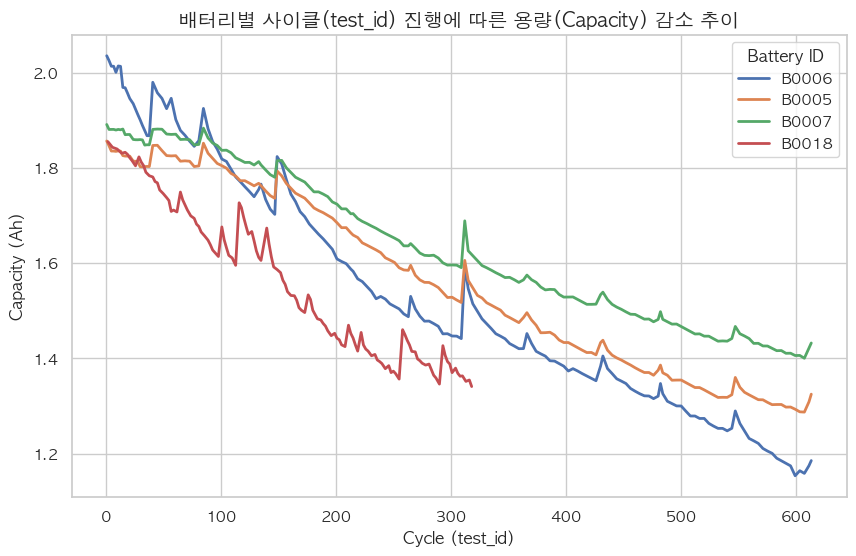

In [31]:
plt.figure(figsize=(10, 6))

# 선 그래프 버전에 따라 hue(그룹)별로 그림을 그립니다.
sns.lineplot(data=filtered_df, x='test_id', y='Capacity', hue='battery_id', linewidth=2)

plt.title('배터리별 사이클(test_id) 진행에 따른 용량(Capacity) 감소 추이', fontsize=14)
plt.xlabel('Cycle (test_id)', fontsize=12)
plt.ylabel('Capacity (Ah)', fontsize=12)
plt.legend(title='Battery ID')
plt.show()


In [32]:
# Capacity는 방전일 때만 나타나는 값 
# 각 배터리 ID마다 방전 종단 전압이 다르다 
# 2.7V (5), 2.5V (6), 2.2V (7), 2.5V (18)
# EOL(수명 종료) 기준: 용량 30% 감소 (1.4Ah 도달 시)

In [33]:
# 추이 -> 배터리 문제가 아닌 껐다 켰을 때 나타나는 오류일수도 있음 

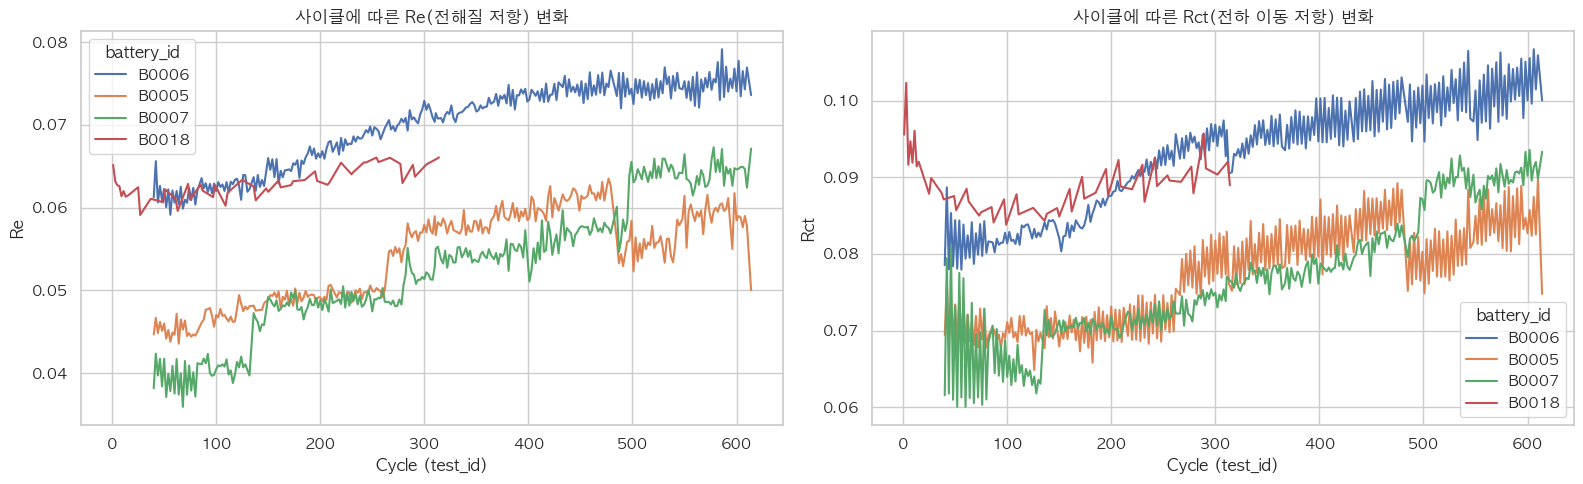

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5)) # 1행 2열로 두 개의 그래프 배치

# 첫 번째 그래프: Re (전해질 저항) 변화
sns.lineplot(data=filtered_df, x='test_id', y='Re', hue='battery_id', ax=axes[0])
axes[0].set_title('사이클에 따른 Re(전해질 저항) 변화')
axes[0].set_xlabel('Cycle (test_id)')
axes[0].set_ylabel('Re')

# 두 번째 그래프: Rct (전하 이동 저항) 변화
sns.lineplot(data=filtered_df, x='test_id', y='Rct', hue='battery_id', ax=axes[1])
axes[1].set_title('사이클에 따른 Rct(전하 이동 저항) 변화')
axes[1].set_xlabel('Cycle (test_id)')
axes[1].set_ylabel('Rct')

plt.tight_layout()
plt.show()


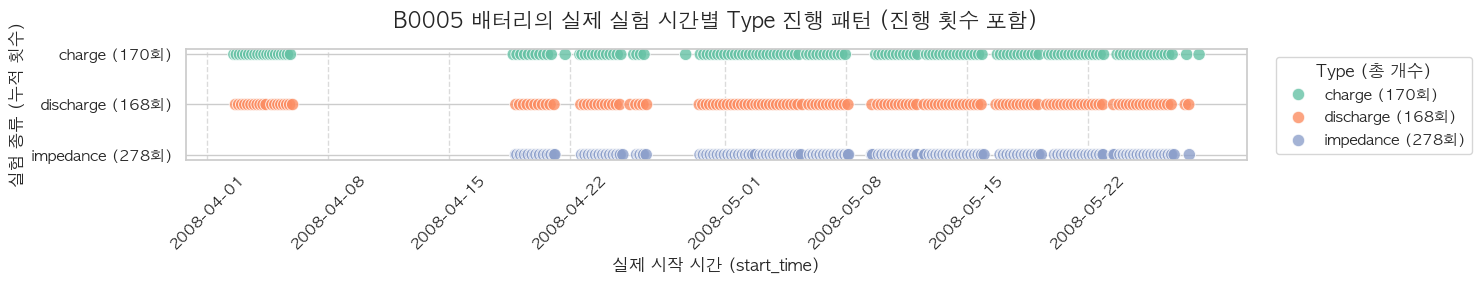

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. B0005 데이터 원본 추출 (이름이 df2였다면 df2로 바꿔주세요)
df_b0005 = df2[df2['battery_id'] == 'B0005'].copy() 

# 2. 날짜(시간) 인식 변환
df_b0005['start_time'] = pd.to_datetime(df_b0005['start_time'])

# -------------------------------------------------------------------
type_counts = df_b0005['type'].value_counts() # 각 타입별 개수 세기

# 'type' 컬럼 대신 개수가 붙은 'type_with_count' 라는 새 텍스트 기둥을 만듭니다.
# 결과 예시: 'charge' -> 'charge (170회)'
df_b0005['type_with_count'] = df_b0005['type'].apply(lambda x: f"{x} ({type_counts[x]}회)")
# -------------------------------------------------------------------

# 3. 캔버스 세팅
plt.figure(figsize=(15, 3))

# 4. 차트 그리기
sns.scatterplot(
    data=df_b0005, 
    x='start_time',       
    y='type_with_count',    
    hue='type_with_count',  
    s=80,              
    alpha=0.8,         
    palette='Set2'     
)

# 5. 데코레이션
plt.title('B0005 배터리의 실제 실험 시간별 Type 진행 패턴 (진행 횟수 포함)', fontsize=15, pad=15)
plt.xlabel('실제 시작 시간 (start_time)', fontsize=12)
plt.ylabel('실험 종류 (누적 횟수)', fontsize=12)

plt.xticks(rotation=45) 
plt.grid(True, axis='x', linestyle='--', alpha=0.7) 

# 범례가 안 가리게 밖으로 쫓아내기
plt.legend(title='Type (총 개수)', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [36]:
# 'B0005', 'B0006', 'B0007', 'B0018' 배터리 대상으로 충전 / 방전 / 임피던스별 data 구성하기

# 대상 배터리 ID 리스트
target_battery_ids = ['B0005', 'B0006', 'B0007', 'B0018']

# 데이터 저장할 폴더 경로
data_folder = "../../dataset/data"

# 데이터를 쌓아두기 위한 저장소(Dictionary) 생성
collected_data = {}

for battery_id in target_battery_ids:
    # 해당 배터리 데이터만 필터링 (시간순 정렬 권장)
    filtered_df = df2[df2['battery_id'] == battery_id].sort_values('start_time')

    # [핵심] 각 배터리 내에서 타입별(충전/방전/임피던스)로 사이클 번호를 관리하기 위한 카운터
    cycle_counters = {'charge': 1, 'discharge': 1, 'impedance': 1}
    
    for _, row in filtered_df.iterrows():
        filename = row['filename']
        file_path = os.path.join(data_folder, filename)

        if os.path.exists(file_path):
            temp_df = pd.read_csv(file_path)
            temp_df['filename'] = filename

            # 현재 행의 타입 확인
            data_type = row['type']

            # 정보 결합
            temp_df['type'] = row['type']
            temp_df['start_time'] = row['start_time']
            temp_df['ambient_temperature'] = row['ambient_temperature']
            temp_df['battery_id'] = row['battery_id']
            temp_df['test_id'] = row['test_id'] 
            temp_df['cycle_index'] = cycle_counters[data_type]

            # 다음 파일을 위해 해당 타입의 카운터 1 증가
            cycle_counters[data_type] += 1

            if row['type'] == 'discharge':
                temp_df['Capacity'] = row['Capacity']
            elif row['type'] == 'impedance':
                temp_df['Re'] = row['Re']
                temp_df['Rct'] = row['Rct']

            # 데이터를 리스트에 추가
            key = f"df_{row['type']}_{battery_id}"
            if key not in collected_data:
                collected_data[key] = []
            collected_data[key].append(temp_df)

# 리스트에 모인 데이터들을 하나로 합치기
for key, df_list in collected_data.items():
    # len(df_list)가 바로 합친 파일(데이터프레임)의 개수입니다.
    file_count = len(df_list) 
    
    globals()[key] = pd.concat(df_list, ignore_index=True)
    
    # 출력 문구에 파일 개수 정보를 추가했습니다.
    print(f"{key} 생성 완료: {file_count}개의 파일 통합됨 | 전체 크기: {globals()[key].shape}")

df_charge_B0005 생성 완료: 170개의 파일 통합됨 | 전체 크기: (541173, 13)
df_discharge_B0005 생성 완료: 168개의 파일 통합됨 | 전체 크기: (50285, 14)
df_impedance_B0005 생성 완료: 278개의 파일 통합됨 | 전체 크기: (13344, 14)
df_charge_B0006 생성 완료: 170개의 파일 통합됨 | 전체 크기: (541173, 13)
df_discharge_B0006 생성 완료: 168개의 파일 통합됨 | 전체 크기: (50285, 14)
df_impedance_B0006 생성 완료: 278개의 파일 통합됨 | 전체 크기: (13344, 14)
df_charge_B0007 생성 완료: 170개의 파일 통합됨 | 전체 크기: (541173, 13)
df_discharge_B0007 생성 완료: 168개의 파일 통합됨 | 전체 크기: (50285, 14)
df_impedance_B0007 생성 완료: 278개의 파일 통합됨 | 전체 크기: (13344, 14)
df_charge_B0018 생성 완료: 134개의 파일 통합됨 | 전체 크기: (279810, 13)
df_impedance_B0018 생성 완료: 53개의 파일 통합됨 | 전체 크기: (2544, 14)
df_discharge_B0018 생성 완료: 132개의 파일 통합됨 | 전체 크기: (34866, 14)


### discharge 분석

In [37]:
# 1. 4개 배터리 데이터를 하나로 통합 (df_battery_discharge)

battery_ids = ['B0005', 'B0006', 'B0007', 'B0018']
all_dfs = []

for b_id in battery_ids:
    df_name = f"df_discharge_{b_id}"
    if df_name in globals():
        # .copy()를 써서 원본 데이터와 연결을 끊고 독립적인 복사본을 만들기
        temp_df = globals()[df_name].copy()
        temp_df['battery_id'] = b_id  # 배터리 식별자 추가
        all_dfs.append(temp_df)

# 통합 데이터프레임 생성
df_battery_discharge = pd.concat(all_dfs, ignore_index=True)

print(f"✅ 통합 완료! 전체 행 개수: {len(df_battery_discharge)}")
print(f"체크 - 포함된 배터리들: {df_battery_discharge['battery_id'].unique()}")

✅ 통합 완료! 전체 행 개수: 185721
체크 - 포함된 배터리들: <StringArray>
['B0005', 'B0006', 'B0007', 'B0018']
Length: 4, dtype: str


In [38]:
df_battery_discharge.dtypes

Voltage_measured               float64
Current_measured               float64
Temperature_measured           float64
Current_load                   float64
Voltage_load                   float64
Time                           float64
filename                           str
type                               str
start_time              datetime64[us]
ambient_temperature              int64
battery_id                         str
test_id                          int64
cycle_index                      int64
Capacity                       float64
dtype: object

In [39]:
df_battery_discharge.head()

,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time,filename,type,start_time,ambient_temperature,battery_id,test_id,cycle_index,Capacity
0,4.191492,-0.004902,24.330034,-0.0006,0.000,0.000,05122.csv,discharge,2008-04-02 15:25:00,24,B0005,1,1,1.856487
1,4.190749,-0.001478,24.325993,-0.0006,4.206,16.781,05122.csv,discharge,2008-04-02 15:25:00,24,B0005,1,1,1.856487
2,3.974871,-2.012528,24.389085,-1.9982,3.062,35.703,05122.csv,discharge,2008-04-02 15:25:00,24,B0005,1,1,1.856487
3,3.951717,-2.013979,24.544752,-1.9982,3.030,53.781,05122.csv,discharge,2008-04-02 15:25:00,24,B0005,1,1,1.856487
4,3.934352,-2.011144,24.731385,-1.9982,3.011,71.922,05122.csv,discharge,2008-04-02 15:25:00,24,B0005,1,1,1.856487


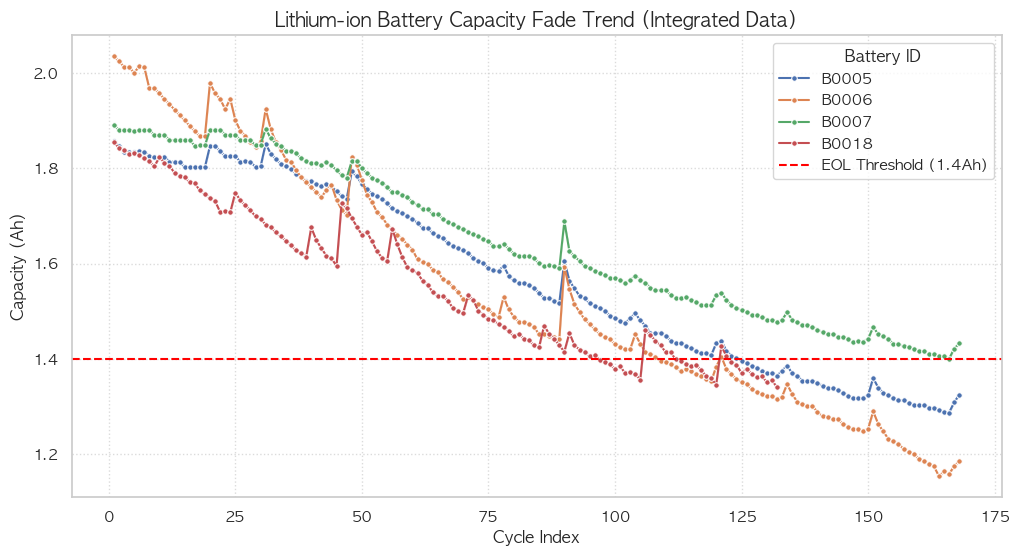

In [40]:

# Capacity 시각화
plt.figure(figsize=(12, 6))

# Seaborn을 사용하면 통합 데이터프레임에서 hue 옵션 하나로 간단히 구분 가능합니다.
sns.lineplot(data=df_battery_discharge, x='cycle_index', y='Capacity', hue='battery_id', marker='o', markersize=4)

# 수명 종료 선 (EOL: End of Life) 설정
plt.axhline(y=1.4, color='red', linestyle='--', label='EOL Threshold (1.4Ah)')

plt.title('Lithium-ion Battery Capacity Fade Trend (Integrated Data)', fontsize=14)
plt.xlabel('Cycle Index')
plt.ylabel('Capacity (Ah)')
plt.legend(title='Battery ID')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()


In [41]:
# '이전 사이클 대비 용량 차이(Diff)' 컬럼을 새로 만듭니다. (음수가 클수록 최악)
df_battery_discharge['Capacity_Drop'] = df_battery_discharge.groupby('battery_id')['Capacity'].diff()

# 배터리별로 용량이 '가장 크게 폭락(가장 큰 음수 값)'했던 사이클(행)을 찾습니다.
worst_drops_idx = df_battery_discharge.groupby('battery_id')['Capacity_Drop'].idxmin()
worst_drops = df_battery_discharge.loc[worst_drops_idx]

print("배터리별 용량이 이전 주차 대비 가장 크게 폭락했던 '최악의 워스트 사이클':")
display(worst_drops[['battery_id', 'test_id', 'Capacity', 'Capacity_Drop','start_time']])


배터리별 용량이 이전 주차 대비 가장 크게 폭락했던 '최악의 워스트 사이클':


,battery_id,test_id,Capacity,Capacity_Drop,start_time
26111,B0005,315,1.563849,-0.041970,2008-05-09 20:28:00
76396,B0006,315,1.546390,-0.047196,2008-05-09 20:28:00
126681,B0007,315,1.625994,-0.062827,2008-05-09 20:28:00
168247,B0018,142,1.640435,-0.033210,2008-08-01 21:32:00


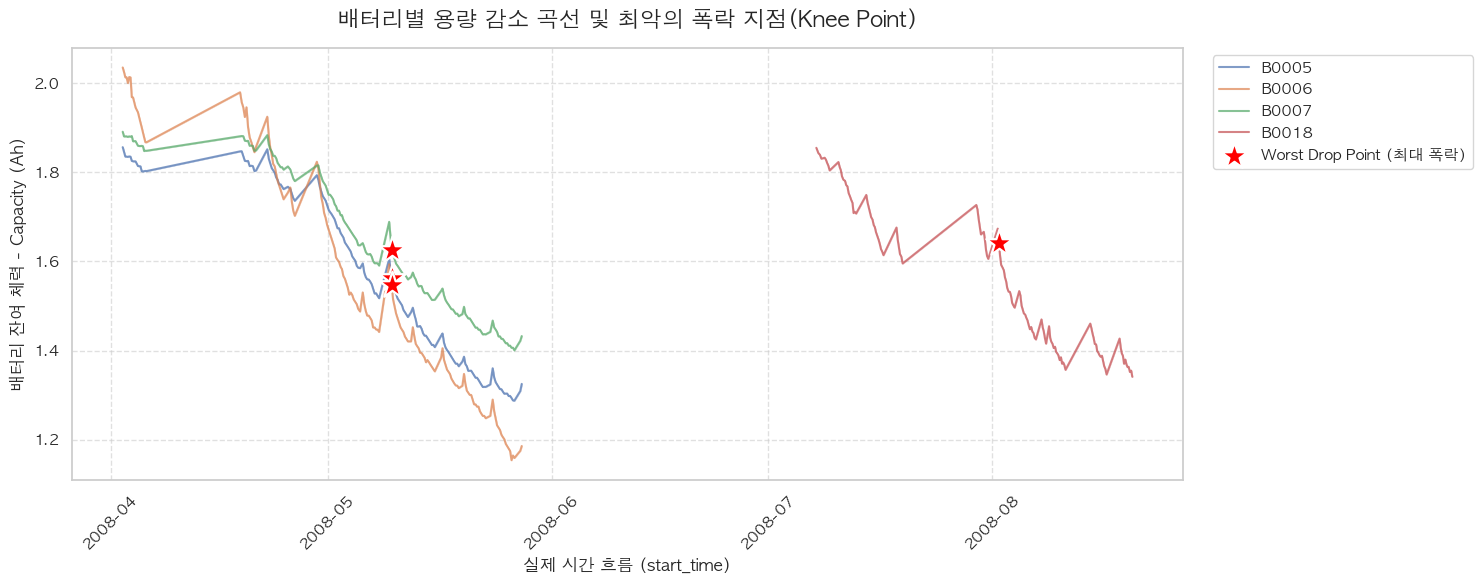

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 캔버스 크기 넉넉하게 설정
plt.figure(figsize=(15, 6))

# 1. 전체 배터리의 용량(Capacity) 감소 추이 선 그래프로 그리기
sns.lineplot(
    data=df_battery_discharge, 
    x='start_time',         # X축: 시간 흐름
    y='Capacity', 
    hue='battery_id', 
    linewidth=1.5,
    alpha=0.7               # 선이 겹쳐도 잘 보이게 살짝 투명하게
)

# 2. 하이라이트: 최악의 폭락 지점(worst_drops)에 빨간색 큰 마커 찍기!
sns.scatterplot(
    data=worst_drops,
    x='start_time',
    y='Capacity',
    color='red',
    s=400,                  # 마커(별) 크기를 아주 크게!
    marker='*',             # 별 모양 마커
    zorder=5,               # 선 아래로 숨지 않고 위로 올라오도록 강제 설정
    label='Worst Drop Point (최대 폭락)'
)

# 3. 그래프 예쁘게 꾸미기
plt.title('배터리별 용량 감소 곡선 및 최악의 폭락 지점(Knee Point)', fontsize=16, pad=15)
plt.xlabel('실제 시간 흐름 (start_time)', fontsize=12)
plt.ylabel('배터리 잔여 체력 - Capacity (Ah)', fontsize=12)

# X축 시간 글씨가 겹치지 않게 기울이기
plt.xticks(rotation=45) 
plt.grid(True, linestyle='--', alpha=0.6)

# 범례(Legend)가 그래프를 가리지 바깥으로 유배 보내기
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

plt.show()


In [43]:
# (주의: 이전에 정의한 df_b0005 프레임을 그대로 씁니다)
# 1. 날짜 데이터에서 '요일(Day Name)'만 쏙 뽑아서 파생 변수를 만듭니다.
df_b0005['day_of_week'] = df_b0005['start_time'].dt.day_name()

# 2. 요일별로 총 몇 번씩 기계를 돌렸는지(측정했는지) 셉니다.
day_counts = df_b0005['day_of_week'].value_counts()

# 3. 월~일 순서대로 예쁘게 정렬해서 보기
week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = day_counts.reindex(week_order)

print("📅 B0005 배터리 요일별 기계 작동(측정) 횟수:")
display(day_counts)


📅 B0005 배터리 요일별 기계 작동(측정) 횟수:


day_of_week
Monday        61
Tuesday       83
Wednesday    105
Thursday      92
Friday        60
Saturday     119
Sunday        96
Name: count, dtype: int64

In [44]:
# 1. 우리의 핵심 4대장 배터리 명단
target_batteries = ['B0005', 'B0006', 'B0007', 'B0018']

# 2. 4개의 배터리를 하나씩 돌아가면서 'TOP 5 빈칸(휴지기)' 추적하기
for battery_id in target_batteries:
    
    # 2-1. 특정 배터리 하나를 시간순 정렬 & 간격 계산
    df_batt = df2[df2['battery_id'] == battery_id].sort_values('start_time').copy()
    
    # 시간 데이터 정확히 파싱
    df_batt['start_time'] = pd.to_datetime(df_batt['start_time'])
    df_batt['day_of_week'] = df_batt['start_time'].dt.day_name()
    df_batt['time_gap'] = df_batt['start_time'].diff()
    
    # 2-2. 해당 배터리에서 시간 간격이 가장 긴 TOP 5 뽑기
    top5_gaps = df_batt.sort_values('time_gap', ascending=False).head(5)
    
    # 2-3. 멋지게 랭킹 발표하기
    print("=" * 60)
    print(f" [{battery_id}] 배터리 역대급 휴지기(기계 꺼짐) TOP 5 ")
    print("=" * 60)
    
    for rank, (idx, row) in enumerate(top5_gaps.iterrows(), 1):
        gap_days = row['time_gap'].days
        gap_hours = row['time_gap'].seconds // 3600
        
        restart_time = row['start_time']
        restart_day = row['day_of_week']
        
        stop_time = restart_time - row['time_gap']
        stop_day = stop_time.day_name()
        
        print(f"{rank}위   {gap_days}일 {gap_hours}시간 동안 멈춤!")
        print(f"   멈춘 날(퇴근): {stop_time.strftime('%Y-%m-%d %H:%M')} [{stop_day}]")
        print(f"   켠 날 (출근): {restart_time.strftime('%Y-%m-%d %H:%M')} [{restart_day}]")
        print("-" * 55)
        
    print("\n") # 다음 배터리로 넘어가기 전에 시원하게 한 줄 띄우기


 [B0005] 배터리 역대급 휴지기(기계 꺼짐) TOP 5 
1위   12일 18시간 동안 멈춤!
   멈춘 날(퇴근): 2008-04-05 22:46 [Saturday]
   켠 날 (출근): 2008-04-18 17:34 [Friday]
-------------------------------------------------------
2위   2일 6시간 동안 멈춤!
   멈춘 날(퇴근): 2008-04-26 10:58 [Saturday]
   켠 날 (출근): 2008-04-28 17:20 [Monday]
-------------------------------------------------------
3위   1일 8시간 동안 멈춤!
   멈춘 날(퇴근): 2008-05-08 03:46 [Thursday]
   켠 날 (출근): 2008-05-09 11:53 [Friday]
-------------------------------------------------------
4위   0일 20시간 동안 멈춤!
   멈춘 날(퇴근): 2008-04-21 17:51 [Monday]
   켠 날 (출근): 2008-04-22 14:15 [Tuesday]
-------------------------------------------------------
5위   0일 18시간 동안 멈춤!
   멈춘 날(퇴근): 2008-04-28 17:20 [Monday]
   켠 날 (출근): 2008-04-29 12:15 [Tuesday]
-------------------------------------------------------


 [B0006] 배터리 역대급 휴지기(기계 꺼짐) TOP 5 
1위   12일 18시간 동안 멈춤!
   멈춘 날(퇴근): 2008-04-05 22:46 [Saturday]
   켠 날 (출근): 2008-04-18 17:34 [Friday]
--------------------------------------------------

### 같은 실험 조건끼리는 분포가 비슷한거 같다

### all_dfs 이상치 처리 

- 전압과 전류 범위 확인
- 온도 데이터 범위 확인
- 용량 데이터 확인 

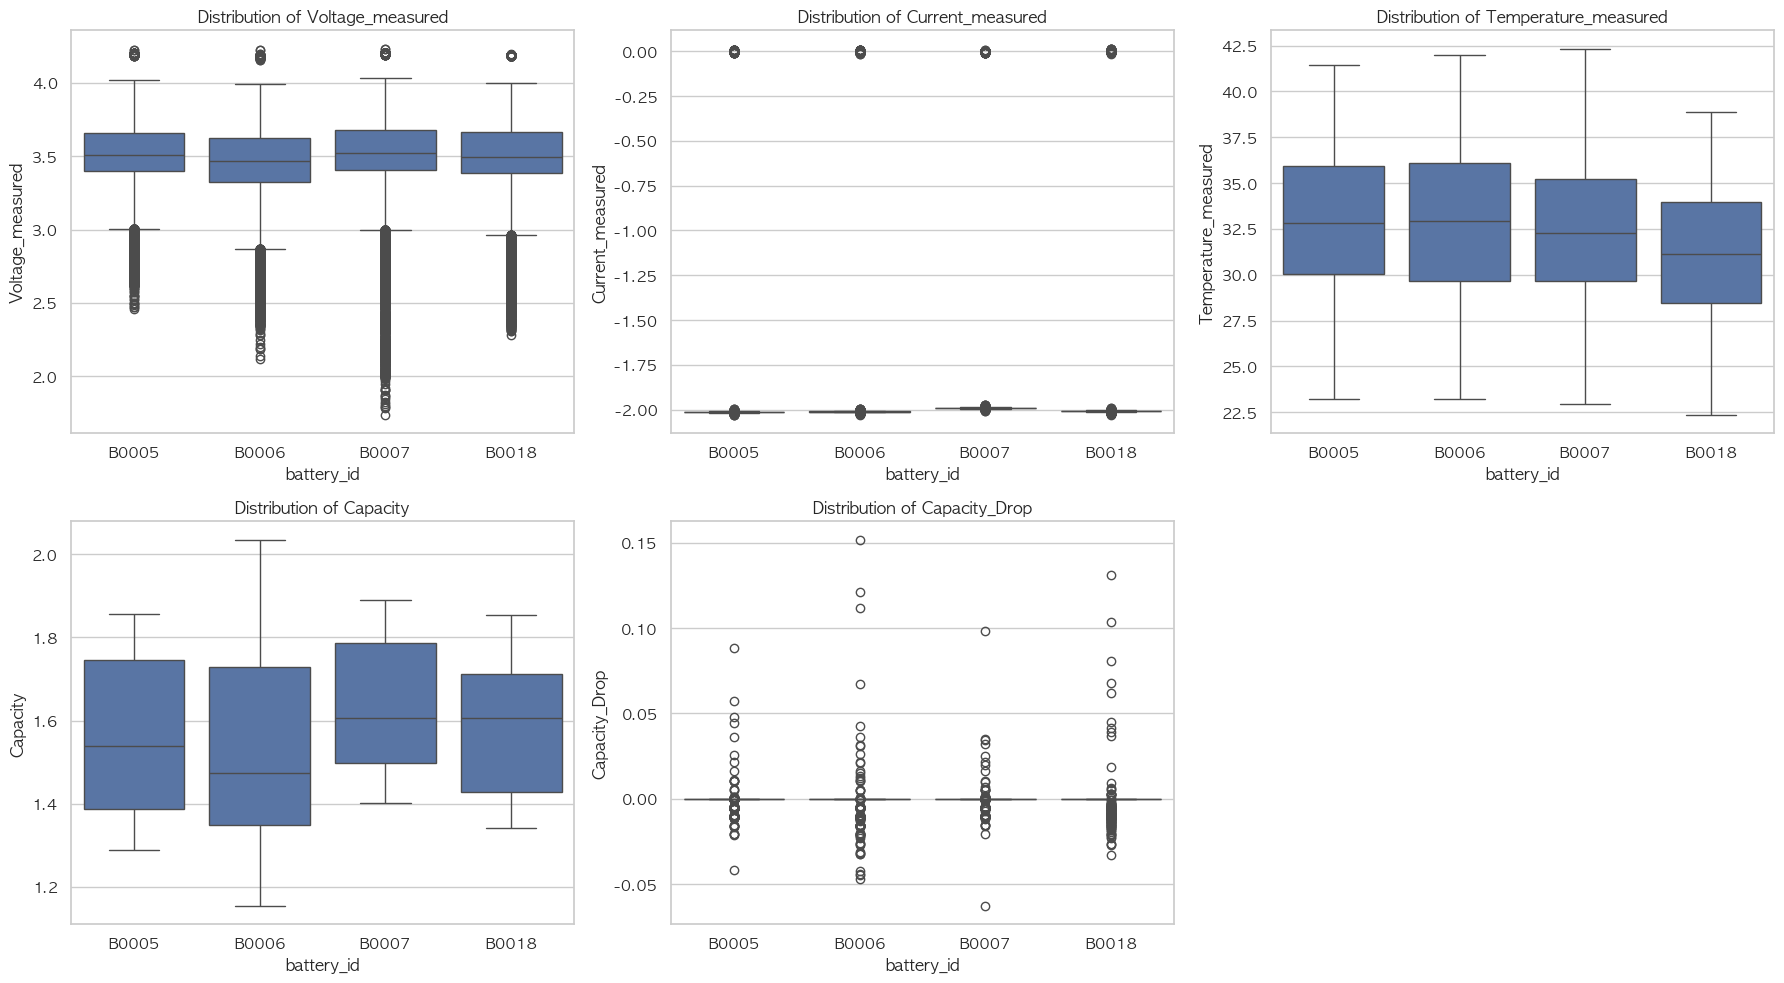

In [45]:
# 수치형 컬럼만 골라서 분포 확인
cols_to_view = ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Capacity', 'Capacity_Drop']

plt.figure(figsize=(18, 10))
for i, col in enumerate(cols_to_view, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='battery_id', y=col, data=df_battery_discharge)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [46]:
# readme 파일에서 
#배터리 번호,방전 중단 전압 (Cut-off)
# 5,2.7V
# 6,2.5V
# 7,2.2V
# 18,2.5V

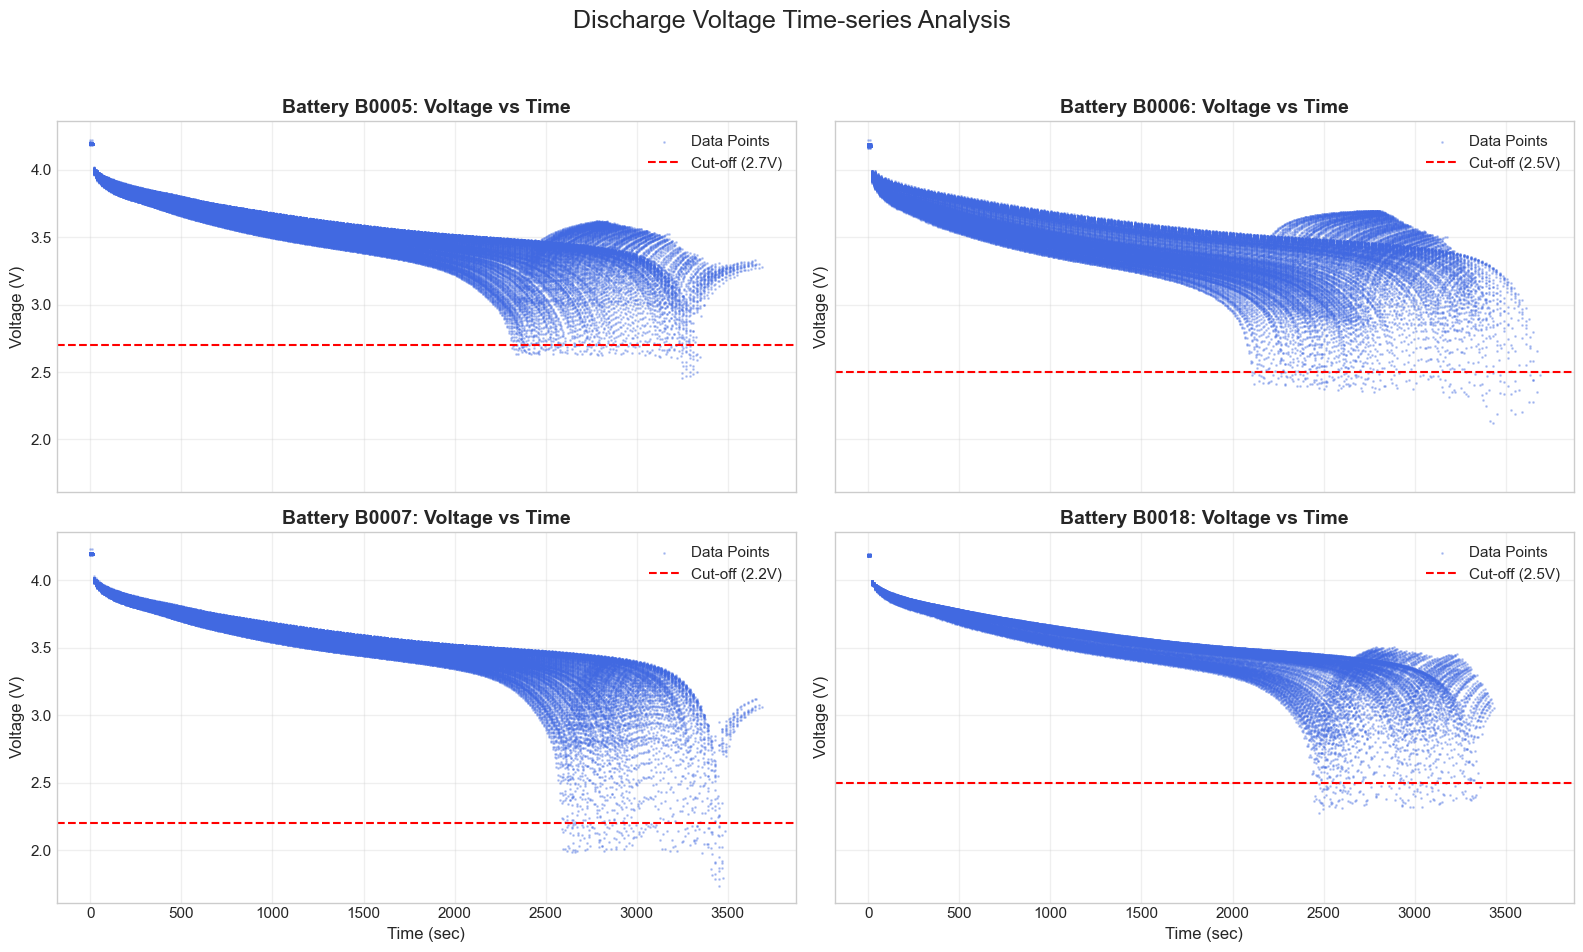

In [47]:
# 그래프 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

# 배터리 ID 목록 (데이터프레임에 있는 실제 ID 확인 필요)
# 보통 'B0005', 'B0006' 등으로 저장되어 있을 겁니다.
battery_ids = sorted(df_battery_discharge['battery_id'].unique())

# 데이터 설명에서 확인한 종지 전압(Cut-off Voltage) 설정
cut_off_dict = {'B0005': 2.7, 'B0006': 2.5, 'B0007': 2.2, 'B0018': 2.5}

for i, bid in enumerate(battery_ids):
    ax = axes[i]
    # 해당 배터리 데이터만 추출
    data = df_battery_discharge[df_battery_discharge['battery_id'] == bid]
    
    # 시계열 그래프 그리기 (투명도를 주어 밀도를 확인)
    ax.scatter(data['Time'], data['Voltage_measured'], s=1, alpha=0.3, color='royalblue', label='Data Points')
    
    # 종지 전압 가이드라인 추가 (이 선 아래로 많이 튀면 이상치!)
    if bid in cut_off_dict:
        cutoff = cut_off_dict[bid]
        ax.axhline(y=cutoff, color='red', linestyle='--', linewidth=1.5, label=f'Cut-off ({cutoff}V)')
    
    ax.set_title(f'Battery {bid}: Voltage vs Time', fontsize=14, fontweight='bold')
    ax.set_ylabel('Voltage (V)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

# 레이아웃 정리
axes[2].set_xlabel('Time (sec)') 
axes[3].set_xlabel('Time (sec)')
plt.suptitle('Discharge Voltage Time-series Analysis', fontsize=18, y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [48]:
# 1. 배터리별 기준(Cut-off) 설정
cut_off_dict = {
    'B0005': 2.7,
    'B0006': 2.5,
    'B0007': 2.2,
    'B0018': 2.5
}

print("=== 배터리별 방전 데이터 이상치(Cut-off 미만) 분석 ===")

# 2. 각 배터리별로 루프를 돌며 개수 계산
for bid, cutoff in cut_off_dict.items():
    # 해당 배터리의 전체 데이터 개수
    total_count = len(df_battery_discharge[df_battery_discharge['battery_id'] == bid])
    
    # 기준치(Cut-off)보다 낮은 데이터 필터링
    outliers = df_battery_discharge[
        (df_battery_discharge['battery_id'] == bid) & 
        (df_battery_discharge['Voltage_measured'] < cutoff)
    ]
    
    outlier_count = len(outliers)
    percentage = (outlier_count / total_count) * 100 if total_count > 0 else 0
    
    print(f"[{bid}]")
    print(f" - 기준 전압: {cutoff}V")
    print(f" - 전체 데이터 수: {total_count:,}개")
    print(f" - 이상치 데이터 수: {outlier_count:,}개")
    print(f" - 이상치 비율: {percentage:.2f}%")
    
    # 만약 이상치가 있다면 최저 전압이 몇까지 떨어졌는지도 확인
    if outlier_count > 0:
        min_v = outliers['Voltage_measured'].min()
        print(f" - 이상치 중 최저 전압: {min_v:.4f}V")
    print("-" * 40)

=== 배터리별 방전 데이터 이상치(Cut-off 미만) 분석 ===
[B0005]
 - 기준 전압: 2.7V
 - 전체 데이터 수: 50,285개
 - 이상치 데이터 수: 168개
 - 이상치 비율: 0.33%
 - 이상치 중 최저 전압: 2.4557V
----------------------------------------
[B0006]
 - 기준 전압: 2.5V
 - 전체 데이터 수: 50,285개
 - 이상치 데이터 수: 168개
 - 이상치 비율: 0.33%
 - 이상치 중 최저 전압: 2.1207V
----------------------------------------
[B0007]
 - 기준 전압: 2.2V
 - 전체 데이터 수: 50,285개
 - 이상치 데이터 수: 168개
 - 이상치 비율: 0.33%
 - 이상치 중 최저 전압: 1.7370V
----------------------------------------
[B0018]
 - 기준 전압: 2.5V
 - 전체 데이터 수: 34,866개
 - 이상치 데이터 수: 132개
 - 이상치 비율: 0.38%
 - 이상치 중 최저 전압: 2.2786V
----------------------------------------


/var/folders/6y/qvnf_sw97x1_0r6dbbkwmpc80000gn/T/ipykernel_48835/787195428.py:26: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6y/qvnf_sw97x1_0r6dbbkwmpc80000gn/T/ipykernel_48835/787195428.py:26: UserWarning: Glyph 50517 (\N{HANGUL SYLLABLE AB}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6y/qvnf_sw97x1_0r6dbbkwmpc80000gn/T/ipykernel_48835/787195428.py:26: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6y/qvnf_sw97x1_0r6dbbkwmpc80000gn/T/ipykernel_48835/787195428.py:26: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6y/qvnf_sw97x1_0r6dbbkwmpc80000gn/T/ipykernel_48835/787195428.py:26: UserWarning: Glyph 47484 (\N{HANGUL SYLLABLE REUL}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6y/qvnf_sw97x1_0r6dbbkwmpc80000gn/T/ipykernel_48835/787195428.py:26: UserWa

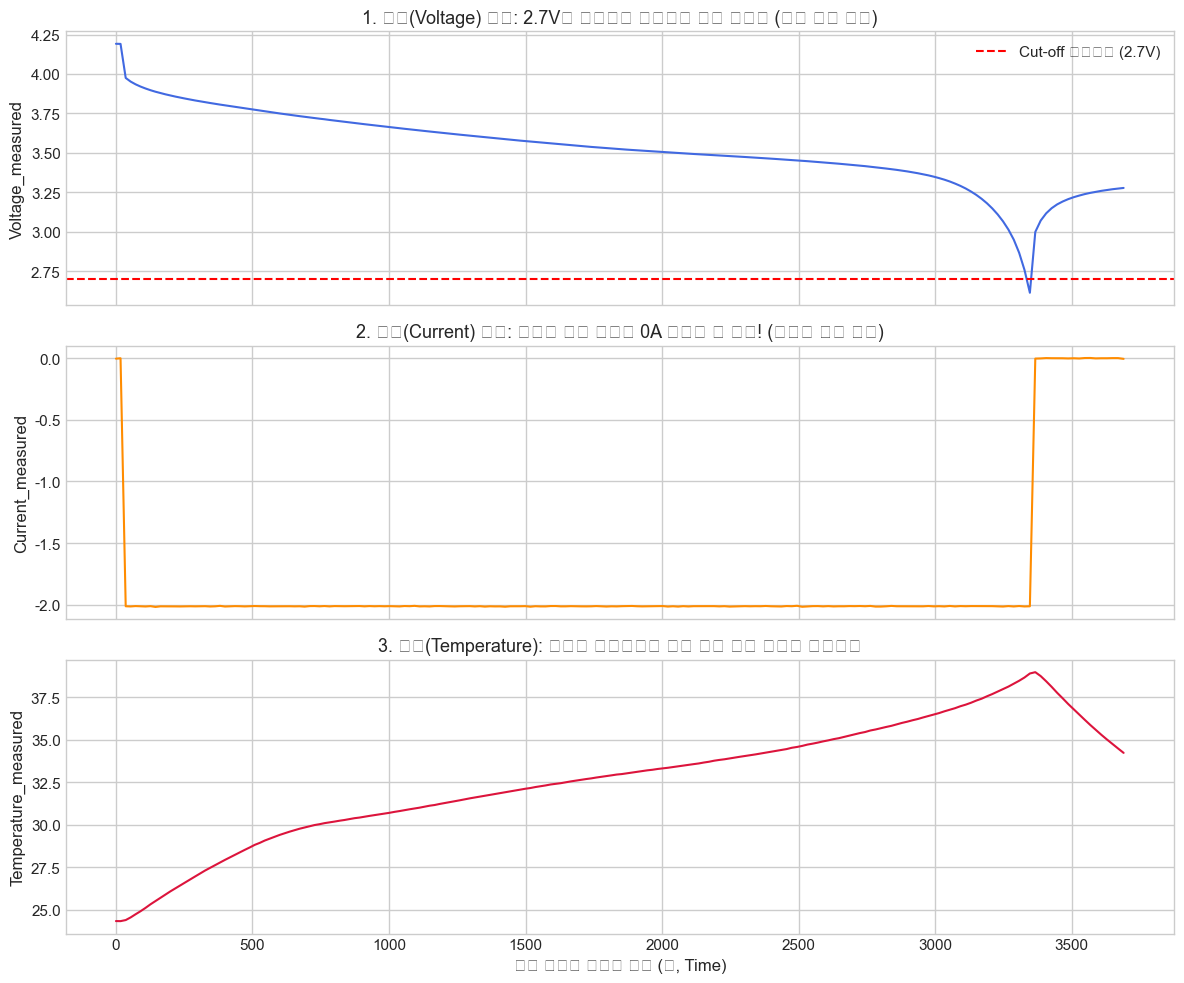

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. B0005 배터리의 '가장 첫 번째 방전 사이클(cycle_index=1)' 데이터 1개만 딱 들고 옵니다.
sample_cycle = df_battery_discharge[(df_battery_discharge['battery_id'] == 'B0005') & 
                                    (df_battery_discharge['cycle_index'] == 1)]

# 2. 증거물 3개를 위아래로 나란히 전시할 3단 도화지 준비
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True) # X축(시간)을 공유합니다.

# 📌 첫 번째: 전압 (Voltage)
sns.lineplot(data=sample_cycle, x='Time', y='Voltage_measured', ax=axes[0], color='royalblue')
axes[0].axhline(y=2.7, color='red', linestyle='--', label='Cut-off 마지노선 (2.7V)')
axes[0].set_title('1. 전압(Voltage) 곡선: 2.7V를 찍자마자 뜬금없이 위로 솟구침 (가짜 회복 구간)', fontsize=13)
axes[0].legend()

# 📌 두 번째: 전류 (Current)
sns.lineplot(data=sample_cycle, x='Time', y='Current_measured', ax=axes[1], color='darkorange')
axes[1].set_title('2. 전류(Current) 흐름: 컷오프 직후 전류가 0A 근처로 뚝 끊김! (기계가 선을 뽑음)', fontsize=13)

# 📌 세 번째: 온도 (Temperature)
sns.lineplot(data=sample_cycle, x='Time', y='Temperature_measured', ax=axes[2], color='crimson')
axes[2].set_title('3. 온도(Temperature): 전류가 끊기자마자 펄펄 끓던 열이 서서히 식어버림', fontsize=13)

plt.xlabel('방전 실험이 진행된 시간 (초, Time)', fontsize=12)
plt.tight_layout()
plt.show()


In [50]:
# 전압이 2.7V 까지 하락
# 전류가 0으로 상승 -> 기계가 배터리에서 선을 뽑았다는 의미 
# 배터리 온도 -> 서서히 식어감 

## cut-off 기준 이후 데이터는 기계가 끝나고 배터리의 스스로 발생하는 현상

In [56]:
df_raw = pd.read_csv("battery_all_integrated.csv")

/var/folders/6y/qvnf_sw97x1_0r6dbbkwmpc80000gn/T/ipykernel_48835/2124209509.py:1: DtypeWarning: Columns (0: Sense_current, 1: Battery_current, 2: Current_ratio, 3: Battery_impedance, 4: Rectified_Impedance) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv("battery_all_integrated.csv")


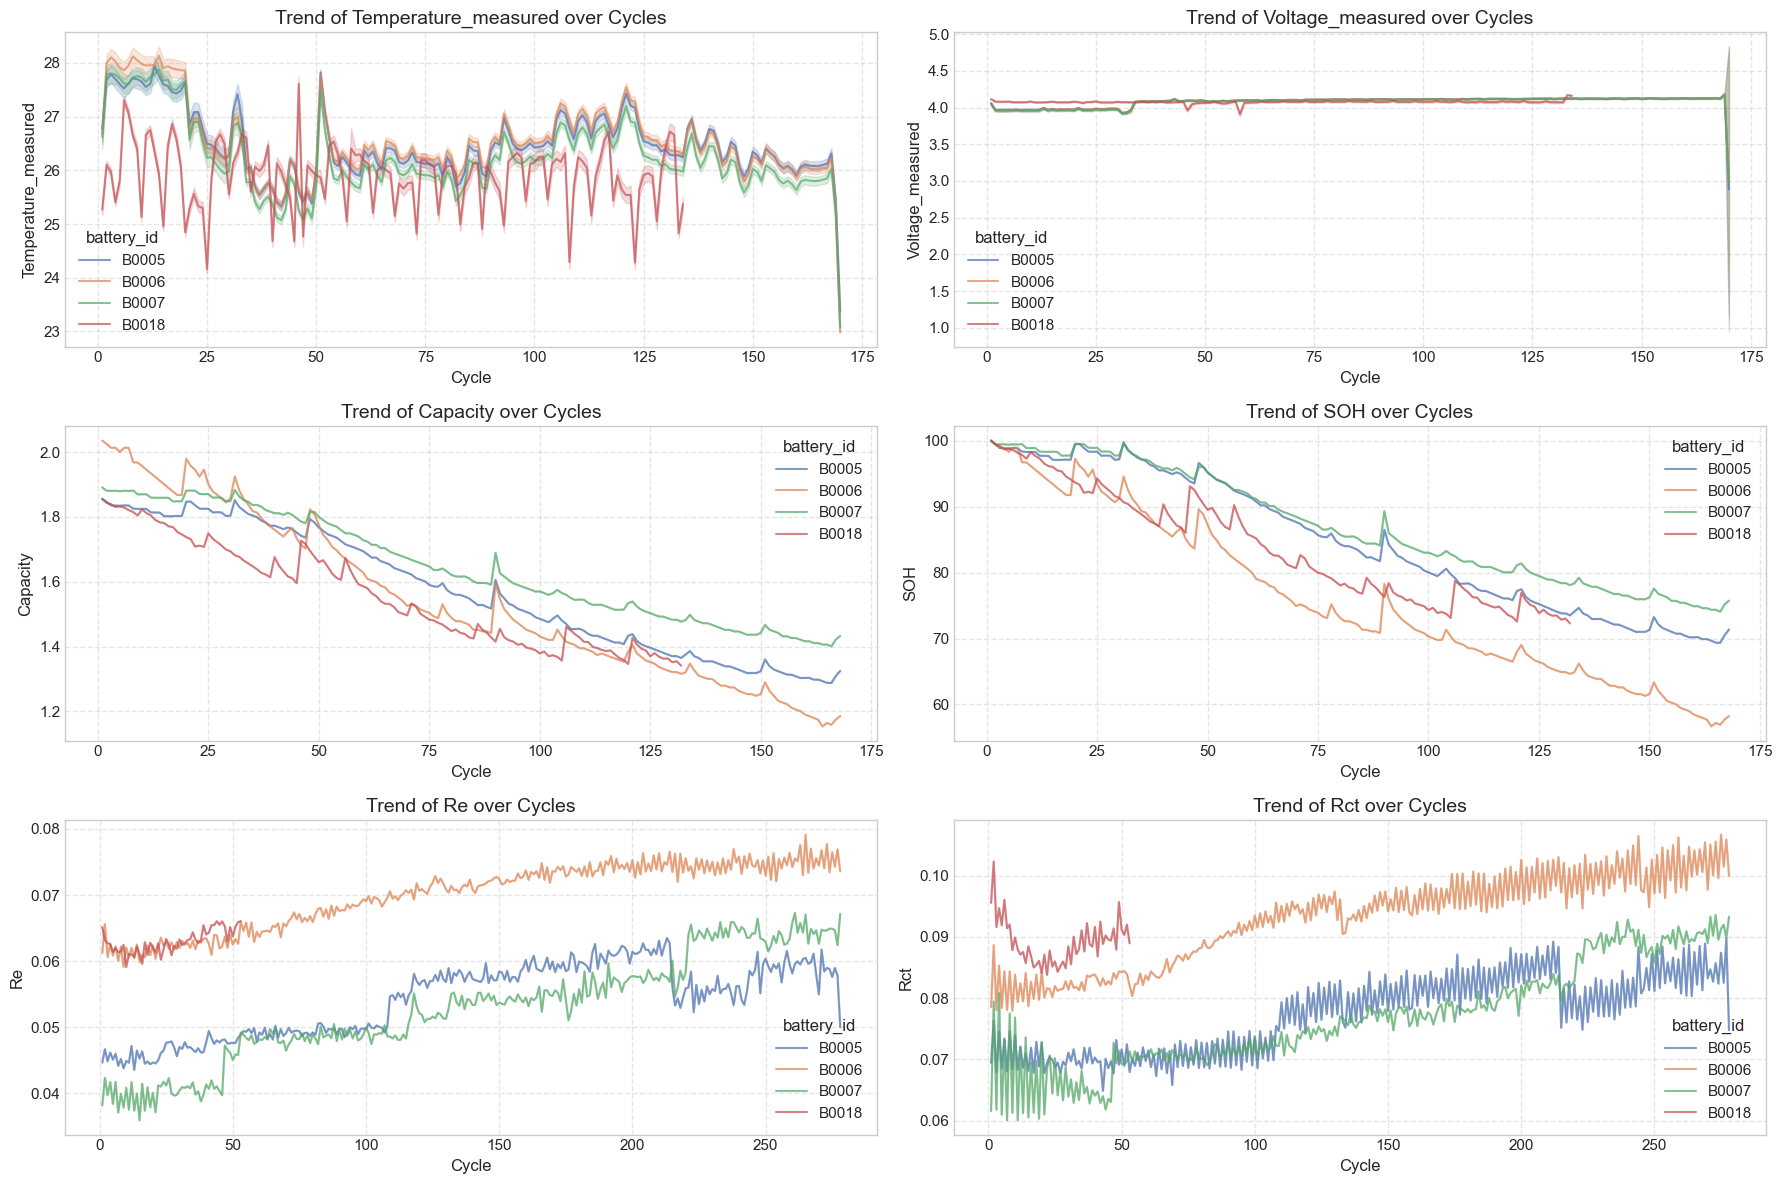

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화할 핵심 컬럼들 (하린님의 리스트에서 선별)
target_features = [
    'Temperature_measured', 'Voltage_measured', 'Capacity', 
    'SOH', 'Re', 'Rct'
]

def plot_battery_behavior(df_raw, features):
    # battery_id가 여러 개라면 색상별로 구분
    plt.figure(figsize=(18, 12))
    
    for i, col in enumerate(features):
        if col in df_raw.columns:
            plt.subplot(3, 2, i + 1)
            # lineplot은 데이터가 많을 때 흐름을 보기 좋습니다.
            sns.lineplot(data=df_raw, x='cycle', y=col, hue='battery_id', alpha=0.7)
            plt.title(f'Trend of {col} over Cycles', fontsize=14)
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.xlabel('Cycle')
            plt.ylabel(col)
        else:
            print(f"⚠️ {col} 컬럼이 데이터프레임에 없습니다.")

    plt.tight_layout()
    plt.show()

# 실행 (df가 하린님의 데이터프레임 이름이라고 가정)
plot_battery_behavior(df_raw, target_features)

### 저항과 방/전류 데이터 관계 살펴본 후 알람 기준 정하기

In [58]:
df_cycle = pd.read_csv("df_cycle_B5671836_NN.csv")

In [62]:
# 배터리 선택 
SELECTED_BATTERIES = ['B0005', 'B0006', 'B0007', 'B0018']


print(f"선택된 배터리: {SELECTED_BATTERIES}")
print(f"전체 배터리:   {df_cycle['battery_id'].unique().tolist()}")

# 선택한 배터리만 필터링 
df_cycle = df_cycle[df_cycle['battery_id'].isin(SELECTED_BATTERIES)].copy()
print(f"필터링 후: {len(df_cycle)}행")
print(f"\n배터리별 데이터 수:")
print(df_cycle['battery_id'].value_counts())

선택된 배터리: ['B0005', 'B0006', 'B0007', 'B0018']
전체 배터리:   ['B0005', 'B0006', 'B0007', 'B0018', 'B0036']
필터링 후: 633행

배터리별 데이터 수:
battery_id
B0005    167
B0006    167
B0007    167
B0018    132
Name: count, dtype: int64


In [63]:
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 분석 대상 컬럼 ─────────────────────────────────
targets = {
    '저항/열화': ['dis_dV_dQ_early', 'dis_IR_drop'],
    '충전/방전': ['cha_t_cv_start', 'cha_ratio_cc', 'dis_time'],
    '환경/통계': ['global_cycle', 'dis_T_max', 'cha_T_max',
                 'cha_V_diff', 'dis_V_diff']
}

resist_cols = ['imp_Re', 'imp_Rct']

# ── 상수값 체크 함수 ────────────────────────────────
def is_constant(series):
    return series.dropna().nunique() <= 1

# ── Re / Rct 각각 출력 ───────────────────────────────
results = []

for resist in resist_cols:
    print(f"\n{'='*85}")
    print(f"기준 저항: {resist}")
    print(f"{'='*85}")
    print(f"{'지표':<20} | {'그룹':<8} | {'피어슨':>9} | {'스피어만':>9} | {'켄달타우':>9} | 비고")
    print(f"{'-'*85}")

    for group_name, cols in targets.items():
        for col in cols:
            tmp = df_cycle[[resist, col]].dropna()

            # 데이터 부족 체크
            if len(tmp) < 10:
                print(f"{col:<20} | {group_name:<8} | "
                      f"데이터 부족 ({len(tmp)}개)")
                continue

            # 상수값 체크
            if is_constant(tmp[resist]) or is_constant(tmp[col]):
                print(f"{col:<20} | {group_name:<8} | "
                      f"상수값 → 제외 (unique: {tmp[col].nunique()}개)")
                continue

            r_p, p_p = stats.pearsonr(tmp[resist], tmp[col])
            r_s, p_s = stats.spearmanr(tmp[resist], tmp[col])
            r_k, p_k = stats.kendalltau(tmp[resist], tmp[col])

            sig_p = "✅" if p_p < 0.05 else "❌"
            sig_s = "✅" if p_s < 0.05 else "❌"
            sig_k = "✅" if p_k < 0.05 else "❌"
            note  = "📈 비선형!" if abs(r_s) - abs(r_p) > 0.05 else ""

            print(f"{col:<20} | {group_name:<8} | "
                  f"{sig_p}{r_p:>+7.3f} | "
                  f"{sig_s}{r_s:>+8.3f} | "
                  f"{sig_k}{r_k:>+8.3f} | {note}")

            results.append({
                'resist':      resist,
                'group':       group_name,
                'feature':     col,
                'r_pearson':   round(r_p, 3),
                'r_spearman':  round(r_s, 3),
                'r_kendall':   round(r_k, 3),
                'p_spearman':  round(p_s, 4),
                'significant': p_s < 0.05,
                'nonlinear':   abs(r_s) - abs(r_p) > 0.05
            })

result_df = pd.DataFrame(results)


기준 저항: imp_Re
지표                   | 그룹       |       피어슨 |      스피어만 |      켄달타우 | 비고
-------------------------------------------------------------------------------------
dis_dV_dQ_early      | 저항/열화    | ✅ +0.801 | ✅  +0.751 | ✅  +0.594 | 
dis_IR_drop          | 저항/열화    | ✅ -0.320 | ✅  -0.372 | ✅  -0.243 | 📈 비선형!
cha_t_cv_start       | 충전/방전    | 상수값 → 제외 (unique: 1개)
cha_ratio_cc         | 충전/방전    | 상수값 → 제외 (unique: 1개)
dis_time             | 충전/방전    | ✅ -0.543 | ✅  -0.506 | ✅  -0.373 | 
global_cycle         | 환경/통계    | ✅ +0.482 | ✅  +0.433 | ✅  +0.322 | 
dis_T_max            | 환경/통계    | ✅ +0.173 | ✅  +0.118 | ✅  +0.115 | 
cha_T_max            | 환경/통계    | ✅ +0.138 | ❌  +0.040 | ✅  +0.065 | 
cha_V_diff           | 환경/통계    | ❌ -0.054 | ✅  -0.419 | ✅  -0.330 | 📈 비선형!
dis_V_diff           | 환경/통계    | ✅ +0.610 | ✅  +0.589 | ✅  +0.444 | 

기준 저항: imp_Rct
지표                   | 그룹       |       피어슨 |      스피어만 |      켄달타우 | 비고
-----------------------------------------------------

In [65]:
# 살펴보기
# ══════════════════════════════════════════════════════
# STEP 1. 문제 확인 — cha_t_cv_start, cha_ratio_cc 실제 값 보기
# ══════════════════════════════════════════════════════

print("=== STEP 1. 문제 컬럼 실제 값 확인 ===")
print()

cols_check = ['cha_t_cv_start', 'cha_ratio_cc']

for col in cols_check:
    print(f"[{col}]")
    print(f"  unique 값 개수: {df_cycle[col].nunique()}")
    print(f"  unique 값들:    {df_cycle[col].unique()}")
    print(f"  상위 5개:")
    print(df_cycle[col].head())
    print()

# 결과: 전부 0.0 → 상수값이라 상관계수 계산 불가

=== STEP 1. 문제 컬럼 실제 값 확인 ===

[cha_t_cv_start]
  unique 값 개수: 1
  unique 값들:    [0.]
  상위 5개:
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: cha_t_cv_start, dtype: float64

[cha_ratio_cc]
  unique 값 개수: 1
  unique 값들:    [0.]
  상위 5개:
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: cha_ratio_cc, dtype: float64



In [66]:
# ══════════════════════════════════════════════════════
# STEP 2. 왜 0.0인지 파악
# — 이 컬럼들이 뭘 의미하는지 먼저 이해
# ══════════════════════════════════════════════════════

print("=== STEP 2. 컬럼 의미 파악 ===")
print()
print("cha_t_cv_start = 충전 중 CC→CV 전환이 시작되는 시점 (초)")
print("cha_ratio_cc   = 전체 충전 시간 중 CC 구간 비율 (0~1)")
print()
print("CC→CV 전환 원리:")
print("  충전 시작 → 전류 일정(CC) → 전압 4.18V 도달 → 전압 고정(CV)")
print("  전압이 4.18V에 도달하는 시점 = CC→CV 전환 시점")
print()
print("→ df_cycle CSV 생성 시 이 계산이 안 됐음 → 전부 0.0")

=== STEP 2. 컬럼 의미 파악 ===

cha_t_cv_start = 충전 중 CC→CV 전환이 시작되는 시점 (초)
cha_ratio_cc   = 전체 충전 시간 중 CC 구간 비율 (0~1)

CC→CV 전환 원리:
  충전 시작 → 전류 일정(CC) → 전압 4.18V 도달 → 전압 고정(CV)
  전압이 4.18V에 도달하는 시점 = CC→CV 전환 시점

→ df_cycle CSV 생성 시 이 계산이 안 됐음 → 전부 0.0


In [67]:
# ══════════════════════════════════════════════════════
# STEP 3. battery_all_integrated 원본에서
#         실제로 전압이 4.18V에 도달하는지 확인
# ══════════════════════════════════════════════════════

print("=== STEP 3. 원본 데이터에서 CV 전환 가능한지 확인 ===")
print()

df_raw = pd.read_csv('battery_all_integrated.csv', low_memory=False)
df_raw['Voltage_measured'] = pd.to_numeric(df_raw['Voltage_measured'], errors='coerce')
df_raw['Time']             = pd.to_numeric(df_raw['Time'],             errors='coerce')

# 충전 구간만
cha_raw = df_raw[df_raw['type'] == 'charge']

# 4.18V 이상 도달한 행 수 확인
cv_rows = cha_raw[cha_raw['Voltage_measured'] >= 4.18]

print(f"전체 충전 행:            {len(cha_raw):>10,}개")
print(f"4.18V 이상 도달한 행:    {len(cv_rows):>10,}개")
print(f"CV 전환 가능 비율:        {len(cv_rows)/len(cha_raw)*100:.1f}%")
print()

# B0005 cycle 1 샘플 확인
sample = cha_raw[(cha_raw['battery_id'] == 'B0005') & (cha_raw['cycle'] == 1)]
print("B0005 cycle 1 충전 전압 분포:")
print(sample['Voltage_measured'].describe())
print()
print(f"→ 4.18V 이상 행: {len(sample[sample['Voltage_measured'] >= 4.18])}개")

=== STEP 3. 원본 데이터에서 CV 전환 가능한지 확인 ===

전체 충전 행:             1,903,329개
4.18V 이상 도달한 행:     1,452,481개
CV 전환 가능 비율:        76.3%

B0005 cycle 1 충전 전압 분포:
count    789.000000
mean       4.187420
std        0.045794
min        3.479394
25%        4.190885
50%        4.205710
75%        4.206481
max        4.209949
Name: Voltage_measured, dtype: float64

→ 4.18V 이상 행: 623개


In [68]:
# ══════════════════════════════════════════════════════
# STEP 4. 실제로 재계산해보기 (B0005 cycle 1 샘플)
# ══════════════════════════════════════════════════════

print("=== STEP 4. 샘플 1개로 재계산 테스트 ===")
print()

sample = cha_raw[
    (cha_raw['battery_id'] == 'B0005') &
    (cha_raw['cycle'] == 1)
].sort_values('Time')

total_time = sample['Time'].max()
cv_start_rows = sample[sample['Voltage_measured'] >= 4.18]

if len(cv_start_rows) > 0:
    cv_start   = cv_start_rows['Time'].iloc[0]   # CC→CV 전환 시점
    ratio_cc   = cv_start / total_time            # CC 비율
    ratio_cv   = 1 - ratio_cc                     # CV 비율
else:
    cv_start = total_time
    ratio_cc = 1.0
    ratio_cv = 0.0

print(f"총 충전 시간:        {total_time:.1f}초 ({total_time/60:.1f}분)")
print(f"CC→CV 전환 시점:     {cv_start:.1f}초 ({cv_start/60:.1f}분)")
print(f"CC 구간 비율:        {ratio_cc:.3f} ({ratio_cc*100:.1f}%)")
print(f"CV 구간 비율:        {ratio_cv:.3f} ({ratio_cv*100:.1f}%)")
print()
print(f"→ 0.0이 아닌 실제 값이 계산됨! ✅")

=== STEP 4. 샘플 1개로 재계산 테스트 ===

총 충전 시간:        7597.9초 (126.6분)
CC→CV 전환 시점:     546.6초 (9.1분)
CC 구간 비율:        0.072 (7.2%)
CV 구간 비율:        0.928 (92.8%)

→ 0.0이 아닌 실제 값이 계산됨! ✅


In [69]:
# ══════════════════════════════════════════════════════
# STEP 5. 전체 배터리 전체 cycle 재계산
# ══════════════════════════════════════════════════════

print("=== STEP 5. 전체 재계산 ===")
print()

cv_results = []

for (bid, cyc), group in cha_raw.groupby(['battery_id', 'cycle']):
    group      = group.sort_values('Time')
    total_time = group['Time'].max()
    cv_rows    = group[group['Voltage_measured'] >= 4.18]

    if len(cv_rows) > 0 and total_time > 0:
        cv_start  = cv_rows['Time'].iloc[0]
        ratio_cc  = cv_start / total_time
        ratio_cv  = 1 - ratio_cc
    else:
        cv_start = total_time
        ratio_cc = 1.0
        ratio_cv = 0.0

    cv_results.append({
        'battery_id':     bid,
        'global_cycle':          cyc,
        'cha_t_cv_start': cv_start,
        'cha_ratio_cc':   ratio_cc,
        'cv_ratio':       ratio_cv,
        'cc_time_min':    cv_start / 60
    })

cv_df = pd.DataFrame(cv_results)

print(f"재계산 완료: {len(cv_df)}행")
print()
print("재계산 후 unique 값 수:")
print(f"  cha_t_cv_start: {cv_df['cha_t_cv_start'].nunique()}개  ← 0에서 변함!")
print(f"  cha_ratio_cc:   {cv_df['cha_ratio_cc'].nunique()}개  ← 0에서 변함!")
print()
print(cv_df.head(5))

=== STEP 5. 전체 재계산 ===

재계산 완료: 644행

재계산 후 unique 값 수:
  cha_t_cv_start: 634개  ← 0에서 변함!
  cha_ratio_cc:   636개  ← 0에서 변함!

  battery_id  global_cycle  cha_t_cv_start  cha_ratio_cc  cv_ratio  \
0      B0005             1         546.610      0.071942  0.928058   
1      B0005             2        3117.406      0.296444  0.703556   
2      B0005             3        3114.672      0.297073  0.702927   
3      B0005             4        3094.468      0.297605  0.702395   
4      B0005             5        3104.484      0.295800  0.704200   

   cc_time_min  
0     9.110167  
1    51.956767  
2    51.911200  
3    51.574467  
4    51.741400  


In [70]:
# ══════════════════════════════════════════════════════
# STEP 6. df에 재계산값 업데이트 후 재확인
# ══════════════════════════════════════════════════════

print("=== STEP 6. df 업데이트 및 결과 확인 ===")
print()

# 기존 0.0 컬럼 제거 후 재계산값으로 교체
df_fixed = df_cycle.drop(columns=['cha_t_cv_start', 'cha_ratio_cc'], errors='ignore')
df_fixed = df_fixed.merge(
    cv_df[['battery_id', 'global_cycle', 'cha_t_cv_start', 'cha_ratio_cc', 'cv_ratio', 'cc_time_min']],
    on=['battery_id', 'global_cycle'],
    how='left'
)

print("업데이트 전 vs 후:")
print(f"  cha_t_cv_start unique: 1개 → {df_fixed['cha_t_cv_start'].nunique()}개")
print(f"  cha_ratio_cc   unique: 1개 → {df_fixed['cha_ratio_cc'].nunique()}개")
print()

# 다시 상관분석 돌리기
from scipy import stats

for col in ['cha_t_cv_start', 'cha_ratio_cc']:
    tmp = df_fixed[['imp_Re', col]].dropna()
    r_s, p_s = stats.spearmanr(tmp['imp_Re'], tmp[col])
    sig = "✅ 유의" if p_s < 0.05 else "❌ 비유의"
    print(f"{col}: 스피어만 r={r_s:+.3f}, p={p_s:.4f} → {sig}")

# 이후 df를 df_fixed로 교체
df_cycle = df_fixed
print()
print("→ df_cycle 업데이트 완료! 이제 상관분석에 정상적으로 사용 가능 ✅")

=== STEP 6. df 업데이트 및 결과 확인 ===

업데이트 전 vs 후:
  cha_t_cv_start unique: 1개 → 625개
  cha_ratio_cc   unique: 1개 → 627개

cha_t_cv_start: 스피어만 r=-0.682, p=0.0000 → ✅ 유의
cha_ratio_cc: 스피어만 r=-0.674, p=0.0000 → ✅ 유의

→ df_cycle 업데이트 완료! 이제 상관분석에 정상적으로 사용 가능 ✅


In [71]:
# ══════════════════════════════════════════════════════
# 저항 vs 충/방전 지표 전체 상관분석
# ══════════════════════════════════════════════════════
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 분석 대상 ─────────────────────────────────────────
resist_cols = ['imp_Re', 'imp_Rct']

targets = {
    '저항/열화': ['dis_dV_dQ_early', 'dis_IR_drop'],
    '충전/방전': ['cha_t_cv_start', 'cha_ratio_cc', 'dis_time'],
    '환경/통계': ['global_cycle', 'dis_T_max', 'cha_T_max',
                 'cha_V_diff', 'dis_V_diff']
}

# ── 상수값 체크 함수 ────────────────────────────────────
def is_constant(series):
    return series.dropna().nunique() <= 1

# ── 상관분석 실행 ──────────────────────────────────────
results = []

for resist in resist_cols:
    print(f"\n{'='*85}")
    print(f"🔋 기준 저항: {resist}")
    print(f"{'='*85}")
    print(f"{'지표':<22} | {'그룹':<8} | {'피어슨':>9} | {'스피어만':>9} | {'켄달타우':>9} | 비고")
    print(f"{'-'*85}")

    for group_name, cols in targets.items():
        for col in cols:

            # 컬럼 존재 확인
            if col not in df_cycle.columns:
                print(f"{col:<22} | {group_name:<8} | ⚠️ 컬럼 없음")
                continue

            tmp = df_cycle[[resist, col]].dropna()

            # 데이터 부족 체크
            if len(tmp) < 10:
                print(f"{col:<22} | {group_name:<8} | "
                      f"⚠️ 데이터 부족 ({len(tmp)}개)")
                continue

            # 상수값 체크
            if is_constant(tmp[resist]) or is_constant(tmp[col]):
                print(f"{col:<22} | {group_name:<8} | "
                      f"⚠️ 상수값 제외 (unique: {tmp[col].nunique()}개)")
                continue

            r_p, p_p = stats.pearsonr(tmp[resist],  tmp[col])
            r_s, p_s = stats.spearmanr(tmp[resist], tmp[col])
            r_k, p_k = stats.kendalltau(tmp[resist], tmp[col])

            sig_p = "✅" if p_p < 0.05 else "❌"
            sig_s = "✅" if p_s < 0.05 else "❌"
            sig_k = "✅" if p_k < 0.05 else "❌"
            note  = "📈 비선형!" if abs(r_s) - abs(r_p) > 0.05 else ""

            print(f"{col:<22} | {group_name:<8} | "
                  f"{sig_p}{r_p:>+7.3f} | "
                  f"{sig_s}{r_s:>+8.3f} | "
                  f"{sig_k}{r_k:>+8.3f} | {note}")

            results.append({
                'resist':      resist,
                'group':       group_name,
                'feature':     col,
                'r_pearson':   round(r_p, 3),
                'r_spearman':  round(r_s, 3),
                'r_kendall':   round(r_k, 3),
                'p_spearman':  round(p_s, 4),
                'significant': p_s < 0.05,
                'nonlinear':   abs(r_s) - abs(r_p) > 0.05
            })

result_df = pd.DataFrame(results)


🔋 기준 저항: imp_Re
지표                     | 그룹       |       피어슨 |      스피어만 |      켄달타우 | 비고
-------------------------------------------------------------------------------------
dis_dV_dQ_early        | 저항/열화    | ✅ +0.801 | ✅  +0.751 | ✅  +0.594 | 
dis_IR_drop            | 저항/열화    | ✅ -0.320 | ✅  -0.372 | ✅  -0.243 | 📈 비선형!
cha_t_cv_start         | 충전/방전    | ✅ -0.693 | ✅  -0.682 | ✅  -0.540 | 
cha_ratio_cc           | 충전/방전    | ✅ -0.690 | ✅  -0.674 | ✅  -0.529 | 
dis_time               | 충전/방전    | ✅ -0.543 | ✅  -0.506 | ✅  -0.373 | 
global_cycle           | 환경/통계    | ✅ +0.482 | ✅  +0.433 | ✅  +0.322 | 
dis_T_max              | 환경/통계    | ✅ +0.173 | ✅  +0.118 | ✅  +0.115 | 
cha_T_max              | 환경/통계    | ✅ +0.138 | ❌  +0.040 | ✅  +0.065 | 
cha_V_diff             | 환경/통계    | ❌ -0.054 | ✅  -0.419 | ✅  -0.330 | 📈 비선형!
dis_V_diff             | 환경/통계    | ✅ +0.610 | ✅  +0.589 | ✅  +0.444 | 

🔋 기준 저항: imp_Rct
지표                     | 그룹       |       피어슨 |      스피어만 |      켄달타우 | 

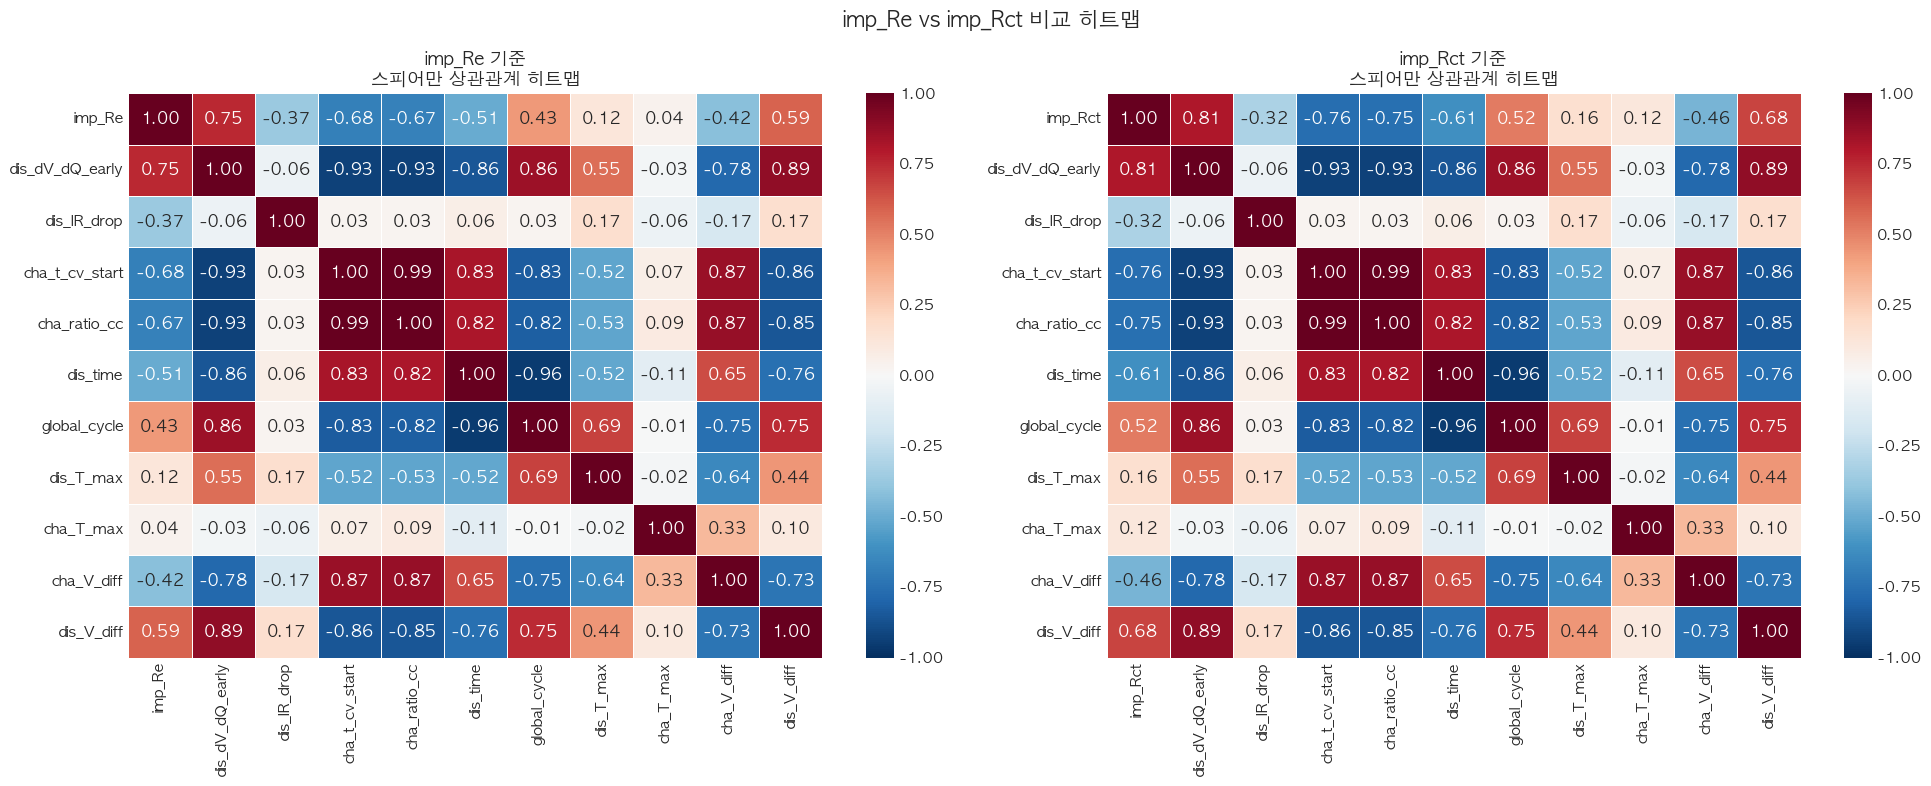

In [73]:
# ── 히트맵 (Re / Rct) ──────────────────────────
valid_cols = [col for cols in targets.values()
              for col in cols
              if col in df_cycle.columns and not is_constant(df_cycle[col])]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, resist in zip(axes, resist_cols):
    corr_cols   = [resist] + valid_cols
    corr_matrix = df_cycle[corr_cols].corr(method='spearman')

    sns.heatmap(
        corr_matrix,
        annot=True, fmt='.2f',
        cmap='RdBu_r', center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        ax=ax
    )
    ax.set_title(f'{resist} 기준\n스피어만 상관관계 히트맵', fontsize=13)

plt.suptitle('imp_Re vs imp_Rct 비교 히트맵', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [74]:
# ── Re vs Rct 결과 비교 요약표 ────────────────────────
print("\n" + "=" * 70)
print("📊 Re vs Rct 핵심 지표 비교 (스피어만 |r| > 0.3 & p < 0.05)")
print("=" * 70)
print(f"{'지표':<22} | {'그룹':<8} | {'Re r':>8} | {'Rct r':>8} | 차이 | 비고")
print("-" * 70)

re_df  = result_df[result_df['resist'] == 'imp_Re'].set_index('feature')
rct_df = result_df[result_df['resist'] == 'imp_Rct'].set_index('feature')

for feat in result_df['feature'].unique():
    re_r  = re_df.loc[feat,  'r_spearman'] if feat in re_df.index  else np.nan
    rct_r = rct_df.loc[feat, 'r_spearman'] if feat in rct_df.index else np.nan
    group = re_df.loc[feat, 'group'] if feat in re_df.index else ''

    max_r = max(abs(re_r)  if not np.isnan(re_r)  else 0,
                abs(rct_r) if not np.isnan(rct_r) else 0)

    if max_r >= 0.3:
        re_sig  = "✅" if not np.isnan(re_r)  and abs(re_r)  >= 0.3 else "  "
        rct_sig = "✅" if not np.isnan(rct_r) and abs(rct_r) >= 0.3 else "  "
        diff    = abs(abs(re_r) - abs(rct_r)) if not (np.isnan(re_r) or np.isnan(rct_r)) else np.nan
        diff_mark = "🔺" if not np.isnan(diff) and diff > 0.05 else ""

        print(f"{feat:<22} | {group:<8} | "
              f"{re_sig}{re_r:>+6.3f} | "
              f"{rct_sig}{rct_r:>+6.3f} | "
              f"{diff:>4.3f} | {diff_mark}")


📊 Re vs Rct 핵심 지표 비교 (스피어만 |r| > 0.3 & p < 0.05)
지표                     | 그룹       |     Re r |    Rct r | 차이 | 비고
----------------------------------------------------------------------
dis_dV_dQ_early        | 저항/열화    | ✅+0.751 | ✅+0.810 | 0.059 | 🔺
dis_IR_drop            | 저항/열화    | ✅-0.372 | ✅-0.318 | 0.054 | 🔺
cha_t_cv_start         | 충전/방전    | ✅-0.682 | ✅-0.761 | 0.079 | 🔺
cha_ratio_cc           | 충전/방전    | ✅-0.674 | ✅-0.754 | 0.080 | 🔺
dis_time               | 충전/방전    | ✅-0.506 | ✅-0.611 | 0.105 | 🔺
global_cycle           | 환경/통계    | ✅+0.433 | ✅+0.519 | 0.086 | 🔺
cha_V_diff             | 환경/통계    | ✅-0.419 | ✅-0.463 | 0.044 | 
dis_V_diff             | 환경/통계    | ✅+0.589 | ✅+0.677 | 0.088 | 🔺


In [75]:
# ── 최종 핵심 지표 순위 (Re 기준) ─────────────────────
print("\n" + "=" * 55)
print("🏆 최종 핵심 저항 요인 순위 (Re 기준, 스피어만 |r| 내림차순)")
print("=" * 55)

top = (result_df[
    (result_df['resist']     == 'imp_Re') &
    (result_df['significant'] == True)
].sort_values('r_spearman', key=abs, ascending=False))

print(f"{'순위':<4} | {'지표':<22} | {'그룹':<8} | {'r':>8} | 비고")
print("-" * 55)
for rank, (_, row) in enumerate(top.iterrows(), 1):
    nl = "📈 비선형" if row['nonlinear'] else ""
    print(f"{rank:<4} | {row['feature']:<22} | "
          f"{row['group']:<8} | "
          f"{row['r_spearman']:>+8.3f} | {nl}")


🏆 최종 핵심 저항 요인 순위 (Re 기준, 스피어만 |r| 내림차순)
순위   | 지표                     | 그룹       |        r | 비고
-------------------------------------------------------
1    | dis_dV_dQ_early        | 저항/열화    |   +0.751 | 
2    | cha_t_cv_start         | 충전/방전    |   -0.682 | 
3    | cha_ratio_cc           | 충전/방전    |   -0.674 | 
4    | dis_V_diff             | 환경/통계    |   +0.589 | 
5    | dis_time               | 충전/방전    |   -0.506 | 
6    | global_cycle           | 환경/통계    |   +0.433 | 
7    | cha_V_diff             | 환경/통계    |   -0.419 | 📈 비선형
8    | dis_IR_drop            | 저항/열화    |   -0.372 | 📈 비선형
9    | dis_T_max              | 환경/통계    |   +0.118 | 


### 열화 구간의 추이 살펴보기

In [76]:
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── cycle 기준 구간 3개 ───────────────────────────────
zone_a = df_cycle[(df_cycle['global_cycle'] >= 20) & (df_cycle['global_cycle'] < 40)]
zone_b = df_cycle[(df_cycle['global_cycle'] >= 40) & (df_cycle['global_cycle'] < 60)]
zone_c = df_cycle[(df_cycle['global_cycle'] >= 60) & (df_cycle['global_cycle'] < 80)]

zones       = [zone_a, zone_b, zone_c]
zone_names  = ['cycle 20~40', 'cycle 40~60', 'cycle 60~80']
zone_colors = ['#FFA500', '#FF6347', '#DC143C']

features = ['cha_t_cv_start', 'dis_time', 'dis_T_max']
labels   = ['CC→CV 전환(초)', '방전시간(초)', '방전온도(°C)']

bid_colors = {
    'B0005': 'steelblue', 'B0006': 'orange',
    'B0007': 'green',     'B0018': 'crimson'
}

# ── 데이터 수 확인 ────────────────────────────────────
print('=== cycle 구간별 데이터 수 ===')
for zone, name in zip(zones, zone_names):
    print(f'{name}: {len(zone)}개')
    print(f'  배터리별: {zone["battery_id"].value_counts().to_dict()}')
    print(f'  Rct 평균: {zone["imp_Rct"].mean():.4f}')
    print(f'  SOH 평균: {zone["SOH_target"].mean():.1f}%')
print()

=== cycle 구간별 데이터 수 ===
cycle 20~40: 77개
  배터리별: {'B0018': 20, 'B0005': 19, 'B0006': 19, 'B0007': 19}
  Rct 평균: 0.0747
  SOH 평균: 94.9%
cycle 40~60: 78개
  배터리별: {'B0005': 20, 'B0006': 20, 'B0007': 20, 'B0018': 18}
  Rct 평균: 0.0772
  SOH 평균: 91.0%
cycle 60~80: 80개
  배터리별: {'B0005': 20, 'B0006': 20, 'B0007': 20, 'B0018': 20}
  Rct 평균: 0.0811
  SOH 평균: 84.2%



In [77]:
# ── 기울기 계산 ───────────────────────────────────────
print('=== cycle 구간별 기울기 ===')
print(f'{"지표":<18} | {"cycle 20~40":>12} | {"cycle 40~60":>12} | {"cycle 60~80":>12}')
print('-' * 65)

slope_results = {}

for feat, label in zip(features, labels):
    slopes = []
    for zone in zones:
        tmp = zone[['global_cycle', feat]].dropna()
        if len(tmp) < 5:
            slopes.append(np.nan)
            continue
        model = LinearRegression().fit(tmp[['global_cycle']], tmp[feat])
        slopes.append(model.coef_[0])
    slope_results[feat] = slopes
    print(f'{label:<18} | {slopes[0]:>+12.4f} | {slopes[1]:>+12.4f} | {slopes[2]:>+12.4f}')

=== cycle 구간별 기울기 ===
지표                 |  cycle 20~40 |  cycle 40~60 |  cycle 60~80
-----------------------------------------------------------------
CC→CV 전환(초)        |     -24.7630 |     -10.2568 |     -23.1778
방전시간(초)            |      -7.4942 |      -3.7888 |      -7.3006
방전온도(°C)           |      -0.0093 |      +0.0501 |      +0.0242


/Users/300phrnaver.com/Desktop/bootcamp/project3/sparta_project_3_team11/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/300phrnaver.com/Desktop/bootcamp/project3/sparta_project_3_team11/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/300phrnaver.com/Desktop/bootcamp/project3/sparta_project_3_team11/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/300phrnaver.com/Desktop/bootcamp/project3/sparta_project_3_team11/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fit

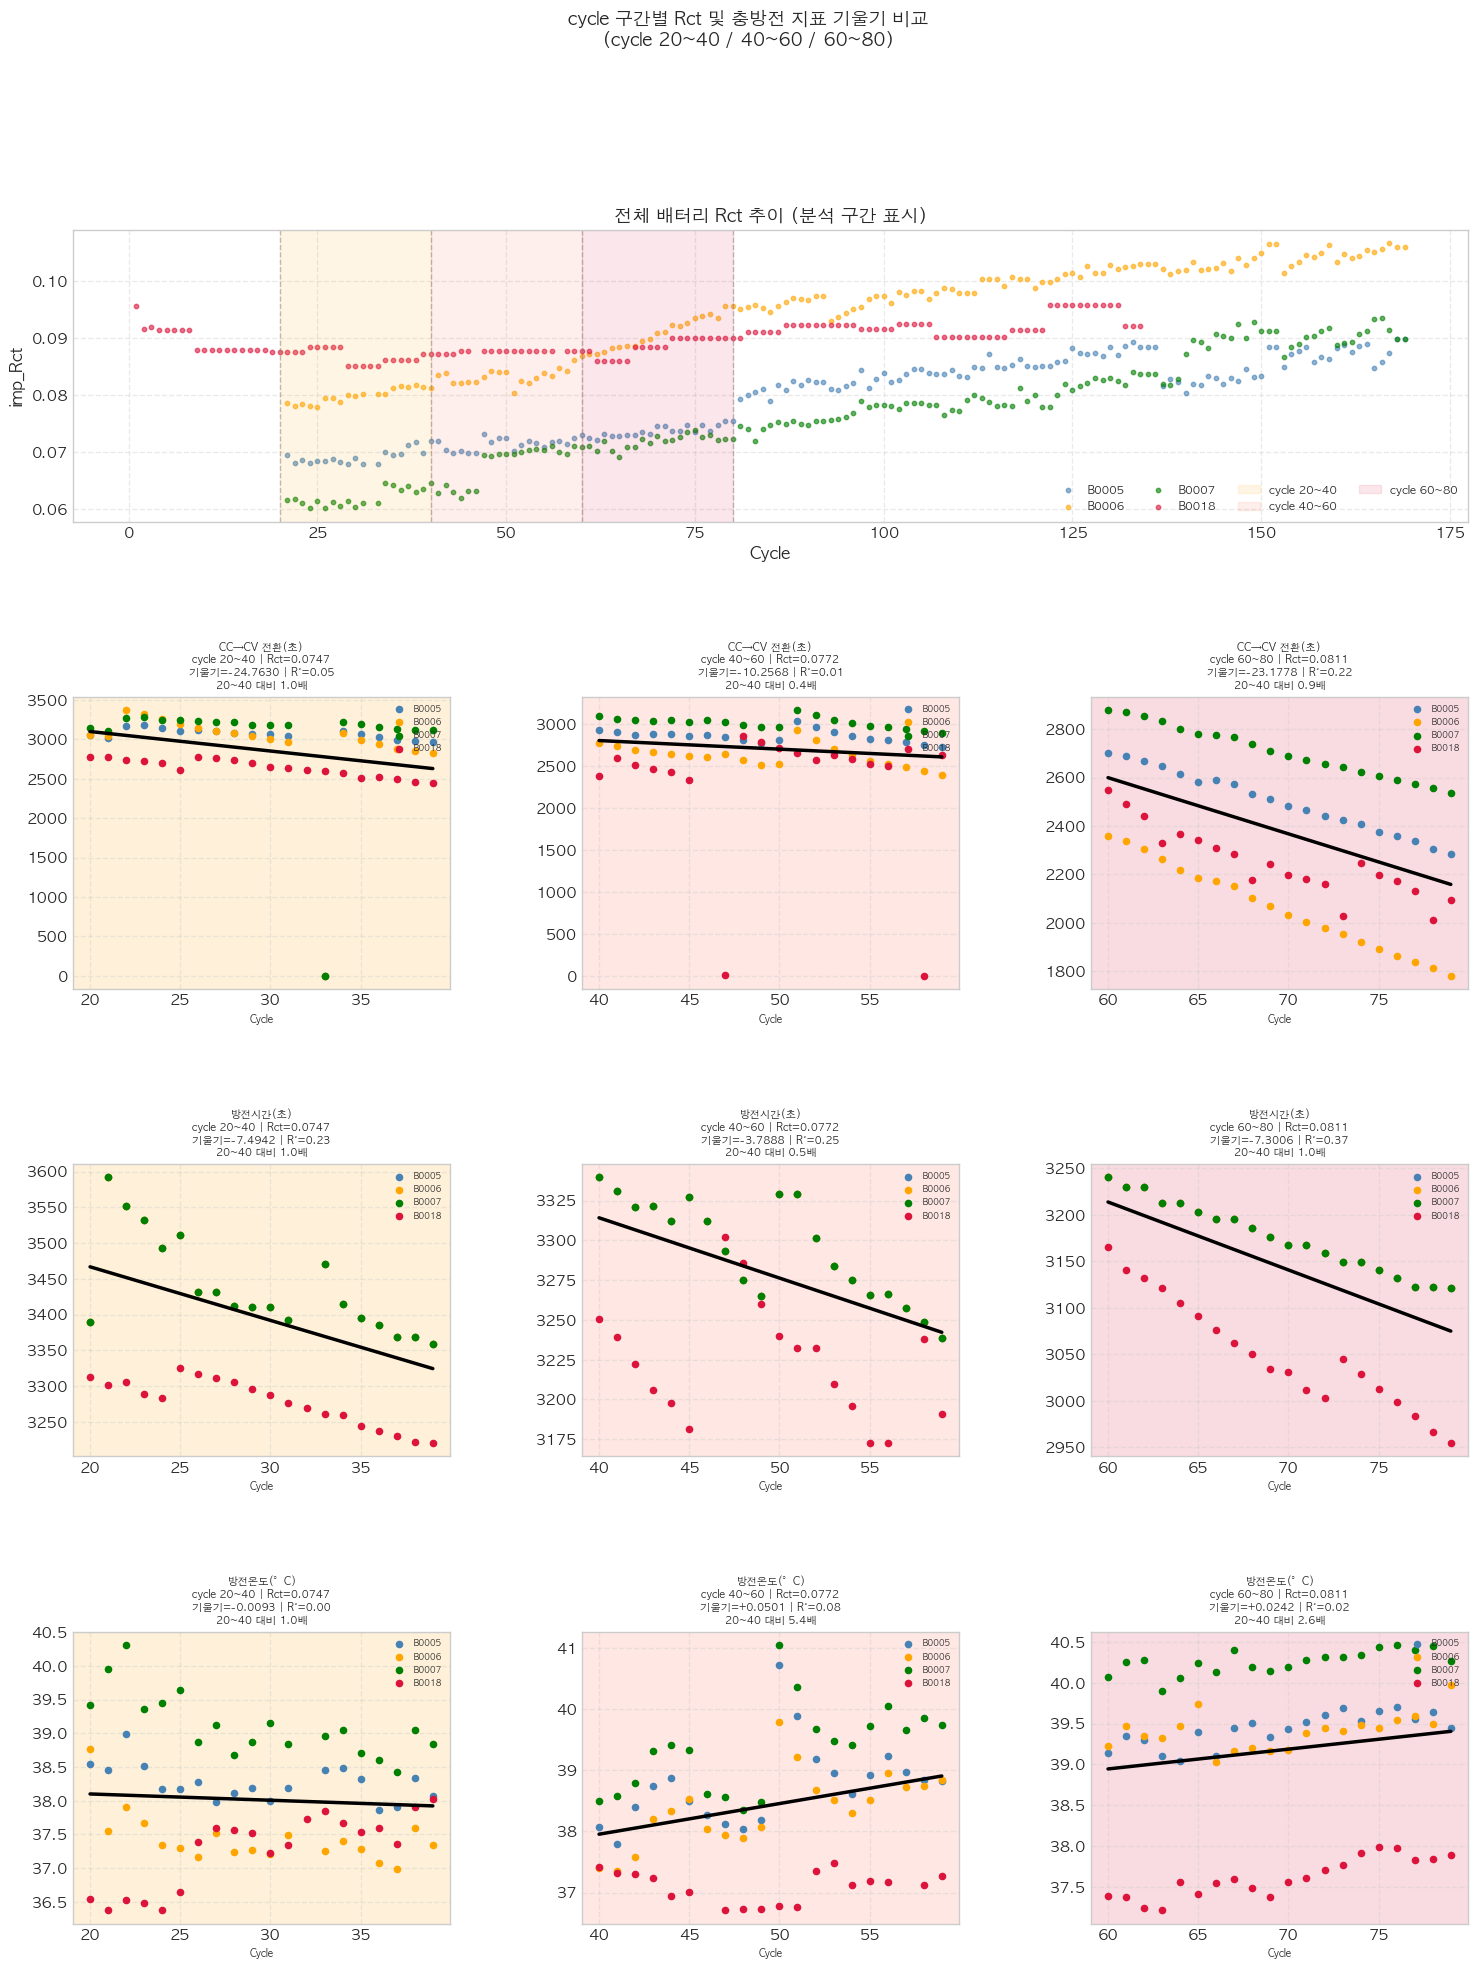

In [78]:
# ── 시각화 ────────────────────────────────────────────

# 행: features 3개 + 상단 Rct 1개 = 총 4행
# 열: 구간 3개
fig = plt.figure(figsize=(18, 22))
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.6, wspace=0.35)

# ══════════════════════════════════════════════════════
# 0행: Rct 전체 추이 (3열 전부 차지)
# ══════════════════════════════════════════════════════
ax_top = fig.add_subplot(gs[0, :])

for bid in df_cycle['battery_id'].unique():
    sub = df_cycle[df_cycle['battery_id'] == bid].sort_values('global_cycle')
    ax_top.scatter(sub['global_cycle'], sub['imp_Rct'],
                   s=10, color=bid_colors.get(bid, 'gray'),
                   alpha=0.6, label=bid)

ax_top.axvspan(20, 40, alpha=0.10, color='orange', label='cycle 20~40')
ax_top.axvspan(40, 60, alpha=0.10, color='tomato', label='cycle 40~60')
ax_top.axvspan(60, 80, alpha=0.10, color='crimson', label='cycle 60~80')
for x in [20, 40, 60, 80]:
    ax_top.axvline(x=x, color='gray', linestyle='--', linewidth=1, alpha=0.5)

ax_top.set_title('전체 배터리 Rct 추이 (분석 구간 표시)', fontsize=13)
ax_top.set_xlabel('Cycle')
ax_top.set_ylabel('imp_Rct')
ax_top.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
ax_top.legend(fontsize=8, ncol=4)
ax_top.grid(True, linestyle='--', alpha=0.4)

# ══════════════════════════════════════════════════════
# 1~3행: 지표 × 구간 서브플롯
# ══════════════════════════════════════════════════════
for row_idx, (feat, label) in enumerate(zip(features, labels)):
    for col_idx, (zone, zname, zcolor) in enumerate(
            zip(zones, zone_names, zone_colors)):

        ax  = fig.add_subplot(gs[row_idx + 1, col_idx])
        tmp = zone[['global_cycle', feat, 'battery_id']].dropna()

        if len(tmp) < 5:
            ax.text(0.5, 0.5, '데이터 부족',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{label}\n{zname}', fontsize=9)
            continue

        # ── 배경색 (patch.set_alpha 제거!) ────────────
        ax.set_facecolor(zcolor)          # 배경색
        ax.patch.set_alpha(0.15)          # 배경만 투명하게

        # ── 배터리별 scatter ───────────────────────────
        for bid in tmp['battery_id'].unique():
            sub_bid = tmp[tmp['battery_id'] == bid]
            ax.scatter(sub_bid['global_cycle'], sub_bid[feat],
                       s=20,
                       color=bid_colors.get(bid, 'gray'),
                       alpha=1.0,         # ← 점은 완전 불투명
                       label=bid,
                       zorder=3)

        # ── 추세선 ────────────────────────────────────
        model  = LinearRegression().fit(tmp[['global_cycle']], tmp[feat])
        x_line = np.linspace(tmp['global_cycle'].min(),
                              tmp['global_cycle'].max(), 100)
        y_line = model.predict(x_line.reshape(-1, 1))
        ax.plot(x_line, y_line,
                color='black', linewidth=2.5, zorder=5)

        slope    = model.coef_[0]
        r2       = model.score(tmp[['global_cycle']], tmp[feat])
        rct_mean = zone['imp_Rct'].mean()

        base  = slope_results[feat][0]
        ratio = abs(slope) / abs(base) if (base and not np.isnan(base)) else 1.0

        ax.set_title(
            f'{label}\n{zname} | Rct={rct_mean:.4f}\n'
            f'기울기={slope:+.4f} | R²={r2:.2f}\n'
            f'20~40 대비 {ratio:.1f}배',
            fontsize=7.5
        )
        ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
        ax.set_xlabel('Cycle', fontsize=7)
        ax.grid(True, linestyle='--', alpha=0.4, zorder=0)

        # ── 범례 모든 서브플롯에 표시 ─────────────────
        ax.legend(fontsize=6,
                  loc='upper right',
                  framealpha=0.8)          # ← col_idx 조건 제거!
                  
plt.suptitle(
    'cycle 구간별 Rct 및 충방전 지표 기울기 비교\n'
    '(cycle 20~40 / 40~60 / 60~80)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('cycle_zone_rct_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
